In [ ]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.0
N0_list = [0.10, 0.20, 0.17, 0.22,0.10, 0.20, 0.17, 0.22]
n_ics = len(N0_list)

numpts = 4 * (24 // 4)
t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)
t_plot = torch.linspace(0.0, 6.0, 200, device=device).view(-1, 1)
N_grid = torch.linspace(0.0, 1.1, 200, device=device).view(-1, 1)


def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data for multiple ICs
#    Noise law is heteroscedastic: sigma_true(N) = 0.07 N
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)


y_true_list = []
y_data_list = []

with torch.no_grad():
    for N0 in N0_list:
        y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
        y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)
        y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true**1

        y_true_list.append(y_true)
        y_data_list.append(y_data)

y_true_all = torch.stack(y_true_list, dim=0)   # [n_ics, numpts, 1]
y_data_all = torch.stack(y_data_list, dim=0)   # [n_ics, numpts, 1]

with torch.no_grad():
    G_grid_true = G_true(N_grid)
    sigma_true_grid = 0.1 * N_grid**1


# ============================================================
# 3. Model classes
# ============================================================
def init_weights_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)


class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, N):
        return self.net(N)


class SigmaNet(nn.Module):
    def __init__(self, hidden_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
            nn.Softplus(),
        )

    def forward(self, N):
        return self.net(N) + 1e-4


# ============================================================
# 4. Helper functions
# ============================================================
def mean_and_ci(arr, ci=1.96):
    arr = np.array(arr)
    mean = arr.mean(axis=0)
    if arr.shape[0] == 1:
        lo = mean.copy()
        hi = mean.copy()
    else:
        sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
        lo = mean - ci * sem
        hi = mean + ci * sem
    return mean, lo, hi


def g_zero_nonnegative_penalty(dyn_net):
    """
    Keep the same form as before:
        penalty = sum(relu(-G(0))^2)
    This is zero when G(0) >= 0, and positive otherwise.
    """
    N_zero = torch.zeros((1, 1), dtype=torch.float32, device=device)
    G_zero = dyn_net(N_zero)
    
    return torch.sum(torch.relu(-G_zero) ** 2)
def gaussian_sigma_nll(resid, sigma):
    sigma2 = sigma ** 2
    return torch.mean(torch.log(sigma2) + (resid ** 2) / sigma2)


def sigma_monotonicity_loss(model, N_col):
    N_req = N_col.clone().detach().requires_grad_(True)
    sigma_col = model(N_req)
    dsigma_dN = torch.autograd.grad(
        outputs=sigma_col,
        inputs=N_req,
        grad_outputs=torch.ones_like(sigma_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    return torch.sum(torch.relu(-dsigma_dN) ** 2)

def fit_sigma_repeated(
    N_all,
    resid_all,
    N_eval_grid,
    N_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=1000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="sigma",
    print_every=500,
):
    n_samples = N_all.shape[0]
    use_validation = val_fraction > 0.0 and n_samples > 1

    if use_validation:
        n_val = int(round(val_fraction * n_samples))
        n_val = max(1, min(n_val, n_samples - 1))
    else:
        n_val = 0
    n_train = n_samples - n_val

    train_total_histories = []
    train_nll_histories = []
    train_mon_histories = []

    val_total_histories = []
    val_nll_histories = []
    val_mon_histories = []

    curve_histories = []
    best_val_losses = []
    best_epochs = []
    best_models = []

    for repeat in range(n_repeats):
        print(f"\n{'-' * 90}")
        print(f"Starting {label} repeat {repeat + 1}/{n_repeats}")
        print(f"{'-' * 90}")

        g = torch.Generator(device=device)
        g.manual_seed(seed_offset_split + repeat)

        perm = torch.randperm(n_samples, generator=g, device=device)
        train_idx = perm[:n_train].sort().values

        if use_validation:
            val_idx = perm[n_train:].sort().values
        else:
            val_idx = torch.empty(0, dtype=torch.long, device=device)

        N_train = N_all[train_idx]
        r_train = resid_all[train_idx]

        if use_validation:
            N_val = N_all[val_idx]
            r_val = resid_all[val_idx]

        torch.manual_seed(seed_offset_model + repeat)
        np.random.seed(seed_offset_model + repeat)

        sigma_net = SigmaNet(hidden_dim=hidden_dim).to(device)
        opt = torch.optim.Adam(sigma_net.parameters(), lr=lr)

        train_total_history = []
        train_nll_history = []
        train_mon_history = []

        val_total_history = []
        val_nll_history = []
        val_mon_history = []

        best_criterion = float("inf")
        best_epoch = -1
        best_state = None

        for epoch in range(n_epochs):
            opt.zero_grad()

            sigma_pred_train = sigma_net(N_train)
            train_nll = gaussian_sigma_nll(r_train, sigma_pred_train)
            train_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            reg = lambda_reg * sum((p ** 2).sum() for p in sigma_net.parameters())

            train_total = train_nll + lambda_mon * train_mon + reg
            train_total.backward()
            opt.step()

            if use_validation:
                with torch.no_grad():
                    sigma_pred_val = sigma_net(N_val)
                    val_nll = gaussian_sigma_nll(r_val, sigma_pred_val)

                val_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
                val_total = val_nll + lambda_mon * val_mon

                criterion_value = val_total.item()
                val_total_item = val_total.item()
                val_nll_item = val_nll.item()
                val_mon_item = val_mon.item()
                criterion_name = "val"
            else:
                criterion_value = train_total.item()
                val_total_item = np.nan
                val_nll_item = np.nan
                val_mon_item = np.nan
                criterion_name = "train"

            train_total_history.append(train_total.item())
            train_nll_history.append(train_nll.item())
            train_mon_history.append(train_mon.item())

            val_total_history.append(val_total_item)
            val_nll_history.append(val_nll_item)
            val_mon_history.append(val_mon_item)

            if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
                if use_validation:
                    print(
                        f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                        f"Epoch {epoch + 1:5d}/{n_epochs} | "
                        f"Train Total: {train_total.item():.6e} | "
                        f"Train NLL: {train_nll.item():.6e} | "
                        f"Train Mon: {train_mon.item():.6e} | "
                        f"Val Total: {val_total_item:.6e} | "
                        f"Val NLL: {val_nll_item:.6e} | "
                        f"Val Mon: {val_mon_item:.6e}"
                    )
                else:
                    print(
                        f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                        f"Epoch {epoch + 1:5d}/{n_epochs} | "
                        f"Train Total: {train_total.item():.6e} | "
                        f"Train NLL: {train_nll.item():.6e} | "
                        f"Train Mon: {train_mon.item():.6e} | "
                        f"Val Total: N/A | Val NLL: N/A | Val Mon: N/A | "
                        f"Best-model criterion: training loss"
                    )

            if criterion_value < best_criterion:
                best_criterion = criterion_value
                best_epoch = epoch
                best_state = copy.deepcopy(sigma_net.state_dict())

        sigma_net.load_state_dict(best_state)
        sigma_net.eval()

        with torch.no_grad():
            sigma_curve = sigma_net(N_eval_grid).squeeze(1).cpu().numpy()

        best_models.append(copy.deepcopy(sigma_net))
        train_total_histories.append(train_total_history)
        train_nll_histories.append(train_nll_history)
        train_mon_histories.append(train_mon_history)

        val_total_histories.append(val_total_history)
        val_nll_histories.append(val_nll_history)
        val_mon_histories.append(val_mon_history)

        curve_histories.append(sigma_curve)
        best_val_losses.append(best_criterion)
        best_epochs.append(best_epoch)

        if use_validation:
            print(
                f"Finished {label} repeat {repeat + 1:2d}/{n_repeats} | "
                f"Best epoch = {best_epoch:5d} | Best val loss = {best_criterion:.6e}"
            )
        else:
            print(
                f"Finished {label} repeat {repeat + 1:2d}/{n_repeats} | "
                f"Best epoch = {best_epoch:5d} | Best train loss = {best_criterion:.6e}"
            )

    return {
        "train_total_histories": np.array(train_total_histories),
        "train_nll_histories": np.array(train_nll_histories),
        "train_mon_histories": np.array(train_mon_histories),
        "val_total_histories": np.array(val_total_histories),
        "val_nll_histories": np.array(val_nll_histories),
        "val_mon_histories": np.array(val_mon_histories),
        "curve_histories": np.array(curve_histories),
        "best_val_losses": np.array(best_val_losses),
        "best_epochs": np.array(best_epochs),
        "best_models": best_models,
    }




Starting PINN split 1/1
Dynamics init seed for split 1: 10000
Solution init seeds for split 1: [20000, 20001, 20002, 20003, 20004, 20005, 20006, 20007]
PINN | Split  1/1 | Epoch     1/5000 | Train Total: 6.431239e-01 | Train Data: 6.401183e-01 | Train Phys: 3.005550e-03 | Train Anchor: 2.817876e-02 | Train g0: 0.000000e+00 | Val Total: 5.248326e-01 | Val Data: 5.220088e-01 | Val Phys: 2.784371e-03 | Val g0: 3.938034e-05
PINN | Split  1/1 | Epoch   500/5000 | Train Total: 5.809890e-03 | Train Data: 5.424562e-03 | Train Phys: 3.853276e-04 | Train Anchor: 2.336756e-03 | Train g0: 0.000000e+00 | Val Total: 3.568517e-03 | Val Data: 3.162830e-03 | Val Phys: 4.056866e-04 | Val g0: 0.000000e+00
PINN | Split  1/1 | Epoch  1000/5000 | Train Total: 5.337930e-03 | Train Data: 5.096383e-03 | Train Phys: 2.415471e-04 | Train Anchor: 1.698820e-03 | Train g0: 0.000000e+00 | Val Total: 3.088978e-03 | Val Data: 2.850525e-03 | Val Phys: 2.384524e-04 | Val g0: 0.000000e+00
PINN | Split  1/1 | Epoch  1500

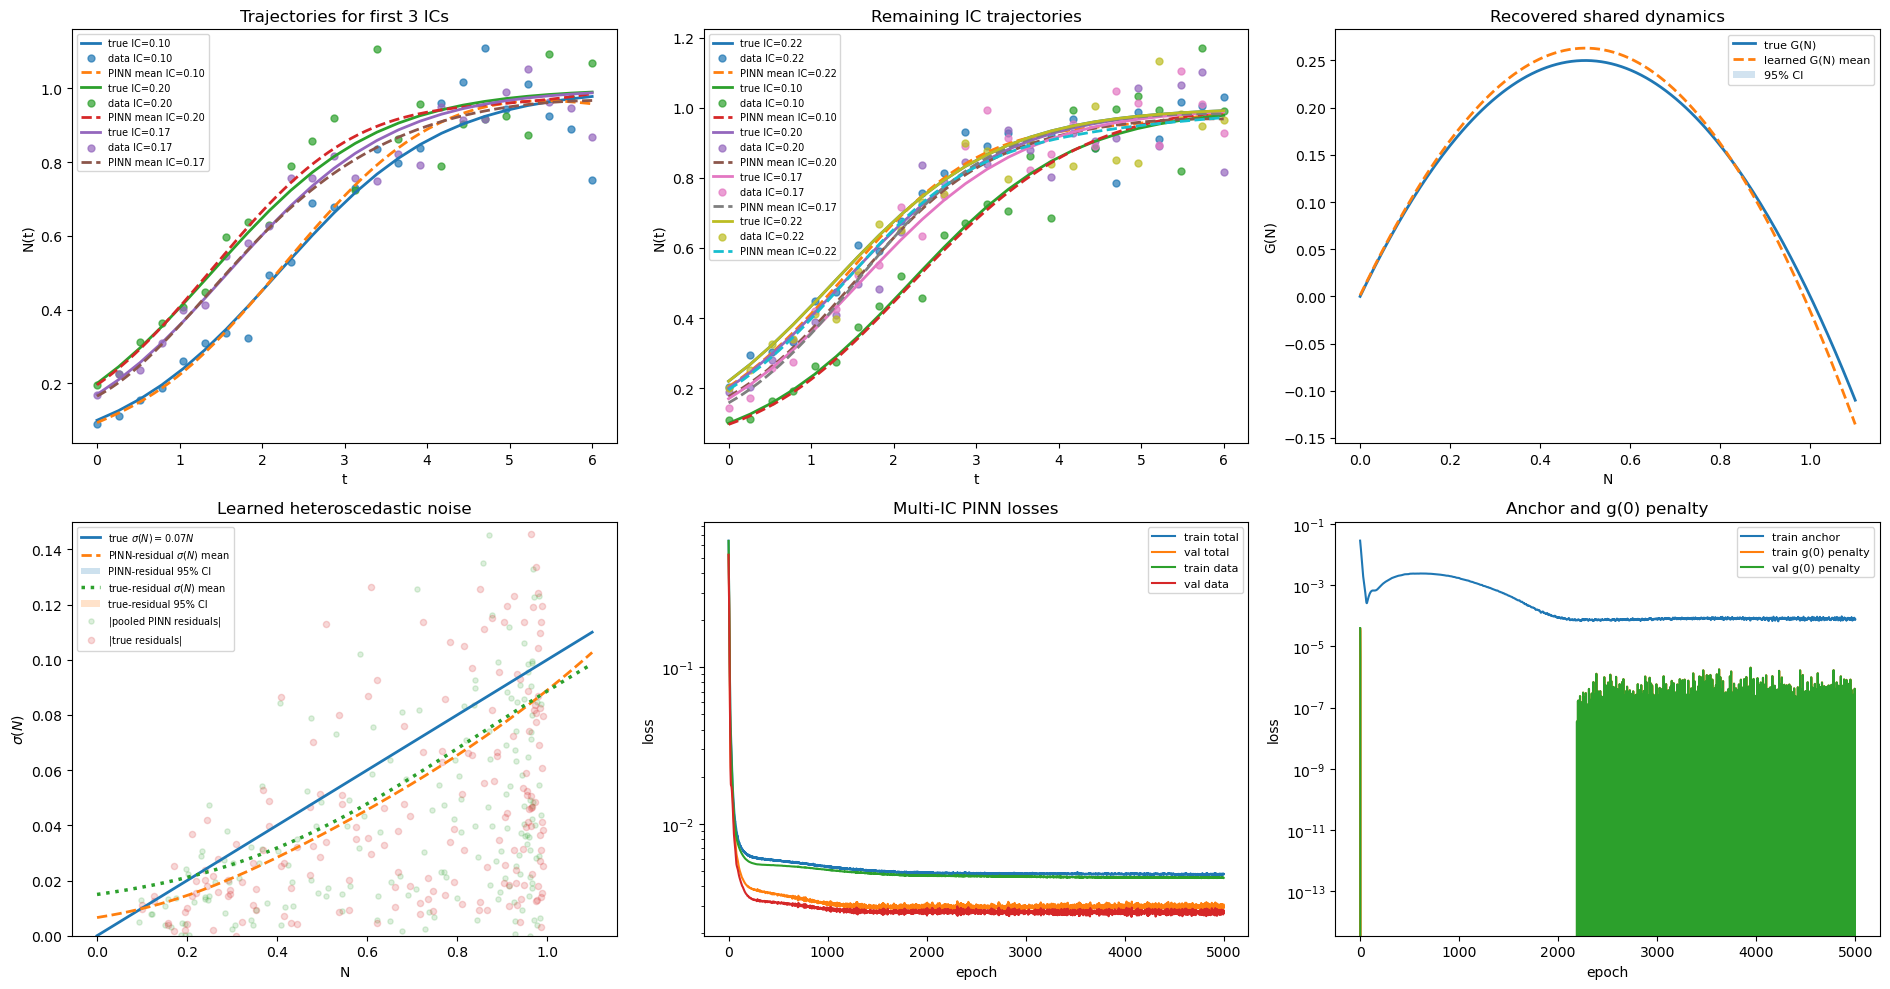

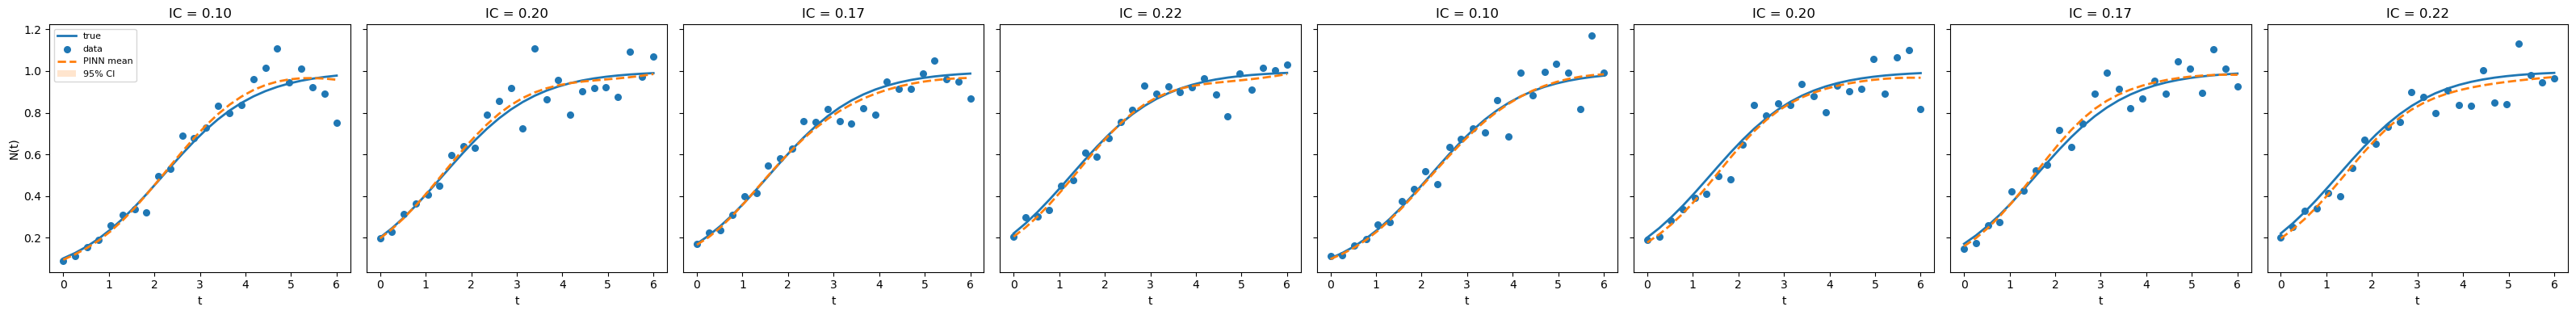

/var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/ipykernel_9670/970698290.py:765: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[0].set_yscale("log")


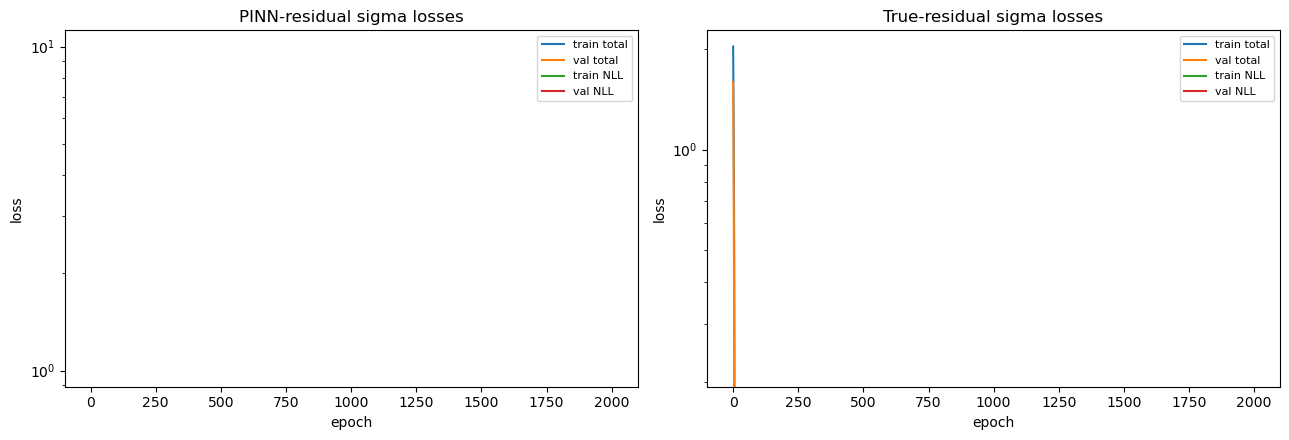


Multi-IC PINN summary
---------------------
Number of trajectories / ICs: 8
Synthetic IC values used to generate data: [0.1, 0.2, 0.17, 0.22, 0.1, 0.2, 0.17, 0.22]
Number of PINN splits: 1
Validation fraction: 0.2
Model-selection criterion: validation loss
Mean best selection loss: 2.757044e-03
Std  best selection loss: nan
Mean best epoch: 2833.00
Std  best epoch: nan
Anchor weight lambda_anchor: 0.000
g(0) nonnegativity weight lambda_g0: 1.000

Initialization summary by split
-------------------------------
Split 1: dyn_init_seed=10000, sol_init_seeds=[20000, 20001, 20002, 20003, 20004, 20005, 20006, 20007], selection_criterion=val

PINN-residual sigma summary
---------------------------
Number of sigma repeats: 1
Mean best selection loss: -4.539145e+00
Std  best selection loss: nan
Mean best epoch: 1999.00
Std  best epoch: nan

True-residual sigma summary
---------------------------
Number of sigma repeats: 1
Mean best selection loss: -4.053282e+00
Std  best selection loss: nan
Mea

In [48]:

def pinn_physics_residual(sol_net, dyn_net, t_col):
    N_pred_col = sol_net(t_col)
    dN_dt = torch.autograd.grad(
        outputs=N_pred_col,
        inputs=t_col,
        grad_outputs=torch.ones_like(N_pred_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    rhs_pred = dyn_net(N_pred_col)
    phys_res = dN_dt - rhs_pred
    return N_pred_col, dN_dt, rhs_pred, phys_res



# ============================================================
# 5. Multi-IC PINN fit across train/validation splits
#    - one shared dyn_net
#    - one sol_net per IC
#    - NO true IC penalty
#    - optional anchor to first observed point
#    - DIVERSE NN INITIALIZATIONS across splits and ICs
#    - if val_fraction == 0, best model is chosen by training loss
#    - g(0) >= 0 enforced as a SEPARATE additional loss term
# ============================================================
n_col = 1000
t_col_base = torch.linspace(0.0, 6.0, n_col, device=device).view(-1, 1)

n_epochs = 5000
n_splits = 1
print_every = 500
batch_obs = 24 * 4 * n_ics
batch_col = 100

val_fraction = 0.2
n_obs = t_obs.shape[0]
use_validation = val_fraction > 0.0 and n_obs > 1

if use_validation:
    n_val = int(round(val_fraction * n_obs))
    n_val = max(1, min(n_val, n_obs - 1))
else:
    n_val = 0
n_train = n_obs - n_val

lambda_phys = 1.0
lambda_anchor = 0.0
lambda_g0 = 1.0
learning_rate = 1e-3
hidden_dim_sol = 32
hidden_dim_dyn = 32

# seeds controlling diverse initializations
data_split_seed_base = 1000
dyn_init_seed_base = 10000
sol_init_seed_base = 20000

train_total_histories = []
train_data_histories = []
train_phys_histories = []
train_anchor_histories = []
train_g0_histories = []

val_total_histories = []
val_data_histories = []
val_phys_histories = []
val_g0_histories = []

traj_histories = []
rhs_histories = []
obs_fit_histories = []

best_val_losses = []
best_epochs = []
best_states = []

for split in range(n_splits):
    print(f"\n{'=' * 90}")
    print(f"Starting PINN split {split + 1}/{n_splits}")
    print(f"{'=' * 90}")

    # -------------------------
    # split-specific data split
    # -------------------------
    g = torch.Generator(device=device)
    g.manual_seed(data_split_seed_base + split)

    perm = torch.randperm(n_obs, generator=g, device=device)
    train_idx = perm[:n_train].sort().values

    if use_validation:
        val_idx = perm[n_train:].sort().values
    else:
        val_idx = torch.empty(0, dtype=torch.long, device=device)

    # -------------------------
    # DIVERSE model initialization
    # - different dyn_net init per split
    # - different sol_net init per split
    # - different sol_net init across ICs
    # -------------------------
    torch.manual_seed(dyn_init_seed_base + split)
    np.random.seed(dyn_init_seed_base + split)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)

    sol_net_list = []
    sol_init_seeds_this_split = []
    for i in range(n_ics):
        init_seed = sol_init_seed_base + 1000 * split + i
        sol_init_seeds_this_split.append(init_seed)
        torch.manual_seed(init_seed)
        np.random.seed(init_seed)
        sol_net_list.append(SolutionNet(hidden_dim=hidden_dim_sol).to(device))

    sol_nets = nn.ModuleList(sol_net_list)

    print(f"Dynamics init seed for split {split + 1}: {dyn_init_seed_base + split}")
    print(f"Solution init seeds for split {split + 1}: {sol_init_seeds_this_split}")

    optimizer = torch.optim.Adam(
        list(dyn_net.parameters()) + list(sol_nets.parameters()),
        lr=learning_rate,
    )

    train_total_history = []
    train_data_history = []
    train_phys_history = []
    train_anchor_history = []
    train_g0_history = []

    val_total_history = []
    val_data_history = []
    val_phys_history = []
    val_g0_history = []

    best_criterion = float("inf")
    best_epoch = -1
    best_state = None

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        total_data_loss = 0.0
        total_phys_loss = 0.0
        total_anchor_loss = 0.0

        for i in range(n_ics):
            sol_net = sol_nets[i]

            # sample observation mini-batch from training indices
            obs_sel = train_idx[torch.randperm(len(train_idx), device=device)[:batch_obs]]
            t_train = t_obs[obs_sel]
            y_train = y_data_all[i][obs_sel]

            N_pred_train = sol_net(t_train)
            data_loss = torch.mean((N_pred_train - y_train) ** 2)

            # resample collocation points each epoch
            t_col = 6.0 * torch.rand(batch_col, 1, device=device)
            t_col.requires_grad_(True)
            _, _, _, phys_res = pinn_physics_residual(sol_net, dyn_net, t_col)
            phys_loss = torch.mean(phys_res ** 2)

            # anchor stays deterministic
            t0_obs = t_obs[0:1]
            y0_obs = y_data_all[i][0:1]
            N0_pred = sol_net(t0_obs)
            anchor_loss = torch.mean((N0_pred - y0_obs) ** 2)

            total_data_loss += data_loss
            total_phys_loss += phys_loss
            total_anchor_loss += anchor_loss

        total_data_loss /= n_ics
        total_phys_loss /= n_ics
        total_anchor_loss /= n_ics

        # Separate additional loss term enforcing g(0) >= 0
        g0_loss = g_zero_nonnegative_penalty(dyn_net)

        train_loss = (
            total_data_loss
            + lambda_phys * total_phys_loss
            + lambda_anchor * total_anchor_loss
            + lambda_g0 * g0_loss
        )
        train_loss.backward()
        optimizer.step()

        if use_validation:
            with torch.no_grad():
                total_val_data_loss = 0.0
                for i in range(n_ics):
                    sol_net = sol_nets[i]
                    t_val = t_obs[val_idx]
                    y_val = y_data_all[i][val_idx]
                    N_pred_val = sol_net(t_val)
                    total_val_data_loss = total_val_data_loss + torch.mean((N_pred_val - y_val) ** 2)

                total_val_data_loss = total_val_data_loss / n_ics

            total_val_phys_loss = 0.0
            for i in range(n_ics):
                sol_net = sol_nets[i]
                t_col_val = t_col_base.clone().detach().requires_grad_(True)
                _, _, _, val_phys_res = pinn_physics_residual(sol_net, dyn_net, t_col_val)
                total_val_phys_loss = total_val_phys_loss + torch.mean(val_phys_res ** 2)

            total_val_phys_loss = total_val_phys_loss / n_ics
            val_g0_loss = g_zero_nonnegative_penalty(dyn_net)

            val_loss = (
                total_val_data_loss
                + lambda_phys * total_val_phys_loss
                + lambda_g0 * val_g0_loss
            )

            criterion_value = val_loss.item()
            criterion_name = "val"

            val_total_item = val_loss.item()
            val_data_item = total_val_data_loss.item()
            val_phys_item = total_val_phys_loss.item()
            val_g0_item = val_g0_loss.item()
        else:
            criterion_value = train_loss.item()
            criterion_name = "train"

            val_total_item = np.nan
            val_data_item = np.nan
            val_phys_item = np.nan
            val_g0_item = np.nan

        train_total_history.append(train_loss.item())
        train_data_history.append(total_data_loss.item())
        train_phys_history.append(total_phys_loss.item())
        train_anchor_history.append(total_anchor_loss.item())
        train_g0_history.append(g0_loss.item())

        val_total_history.append(val_total_item)
        val_data_history.append(val_data_item)
        val_phys_history.append(val_phys_item)
        val_g0_history.append(val_g0_item)

        if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
            if use_validation:
                print(
                    f"PINN | Split {split + 1:2d}/{n_splits} | "
                    f"Epoch {epoch + 1:5d}/{n_epochs} | "
                    f"Train Total: {train_loss.item():.6e} | "
                    f"Train Data: {total_data_loss.item():.6e} | "
                    f"Train Phys: {total_phys_loss.item():.6e} | "
                    f"Train Anchor: {total_anchor_loss.item():.6e} | "
                    f"Train g0: {g0_loss.item():.6e} | "
                    f"Val Total: {val_total_item:.6e} | "
                    f"Val Data: {val_data_item:.6e} | "
                    f"Val Phys: {val_phys_item:.6e} | "
                    f"Val g0: {val_g0_item:.6e}"
                )
            else:
                print(
                    f"PINN | Split {split + 1:2d}/{n_splits} | "
                    f"Epoch {epoch + 1:5d}/{n_epochs} | "
                    f"Train Total: {train_loss.item():.6e} | "
                    f"Train Data: {total_data_loss.item():.6e} | "
                    f"Train Phys: {total_phys_loss.item():.6e} | "
                    f"Train Anchor: {total_anchor_loss.item():.6e} | "
                    f"Train g0: {g0_loss.item():.6e} | "
                    f"Val Total: N/A | Val Data: N/A | Val Phys: N/A | Val g0: N/A | "
                    f"Best-model criterion: training loss"
                )

        if criterion_value < best_criterion:
            best_criterion = criterion_value
            best_epoch = epoch
            best_state = {
                "dyn_net": copy.deepcopy(dyn_net.state_dict()),
                "sol_nets": [copy.deepcopy(sol_net.state_dict()) for sol_net in sol_nets],
                "dyn_init_seed": dyn_init_seed_base + split,
                "sol_init_seeds": sol_init_seeds_this_split.copy(),
                "train_idx": train_idx.clone(),
                "val_idx": val_idx.clone(),
                "selection_criterion": criterion_name,
            }

    if use_validation:
        print(
            f"Finished PINN split {split + 1:2d}/{n_splits} | "
            f"Best epoch = {best_epoch:5d} | Best val loss = {best_criterion:.6e}"
        )
    else:
        print(
            f"Finished PINN split {split + 1:2d}/{n_splits} | "
            f"Best epoch = {best_epoch:5d} | Best train loss = {best_criterion:.6e}"
        )

    dyn_net.load_state_dict(best_state["dyn_net"])
    for i in range(n_ics):
        sol_nets[i].load_state_dict(best_state["sol_nets"][i])

    dyn_net.eval()
    for sol_net in sol_nets:
        sol_net.eval()

    with torch.no_grad():
        trajs_this_split = []
        obs_fits_this_split = []

        for i in range(n_ics):
            trajs_this_split.append(sol_nets[i](t_plot).squeeze(1).cpu().numpy())
            obs_fits_this_split.append(sol_nets[i](t_obs).squeeze(1).cpu().numpy())

        G_grid_learned = dyn_net(N_grid).squeeze(1).cpu().numpy()

    train_total_histories.append(train_total_history)
    train_data_histories.append(train_data_history)
    train_phys_histories.append(train_phys_history)
    train_anchor_histories.append(train_anchor_history)
    train_g0_histories.append(train_g0_history)

    val_total_histories.append(val_total_history)
    val_data_histories.append(val_data_history)
    val_phys_histories.append(val_phys_history)
    val_g0_histories.append(val_g0_history)

    traj_histories.append(np.array(trajs_this_split))
    obs_fit_histories.append(np.array(obs_fits_this_split))
    rhs_histories.append(G_grid_learned)

    best_val_losses.append(best_criterion)
    best_epochs.append(best_epoch)
    best_states.append(best_state)

train_total_histories = np.array(train_total_histories)
train_data_histories = np.array(train_data_histories)
train_phys_histories = np.array(train_phys_histories)
train_anchor_histories = np.array(train_anchor_histories)
train_g0_histories = np.array(train_g0_histories)

val_total_histories = np.array(val_total_histories)
val_data_histories = np.array(val_data_histories)
val_phys_histories = np.array(val_phys_histories)
val_g0_histories = np.array(val_g0_histories)

traj_histories = np.array(traj_histories)         # [n_splits, n_ics, len(t_plot)]
obs_fit_histories = np.array(obs_fit_histories)   # [n_splits, n_ics, len(t_obs)]
rhs_histories = np.array(rhs_histories)

rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)

traj_mean_per_ic = []
traj_lo_per_ic = []
traj_hi_per_ic = []

obs_fit_mean_per_ic = []
obs_fit_lo_per_ic = []
obs_fit_hi_per_ic = []

for i in range(n_ics):
    m, lo, hi = mean_and_ci(traj_histories[:, i, :])
    traj_mean_per_ic.append(m)
    traj_lo_per_ic.append(lo)
    traj_hi_per_ic.append(hi)

    m, lo, hi = mean_and_ci(obs_fit_histories[:, i, :])
    obs_fit_mean_per_ic.append(m)
    obs_fit_lo_per_ic.append(lo)
    obs_fit_hi_per_ic.append(hi)


# ============================================================
# 6. Learn sigma(N) from pooled multi-IC PINN residuals
#    residual = y_data - N_hat_PINN
# ============================================================
with torch.no_grad():
    y_rep = y_data_all.squeeze(-1).cpu().numpy()[None, :, :]
    resid_pinn_all_np = y_rep - obs_fit_histories

    N_pinn_sigma_all_np = obs_fit_histories.reshape(-1, 1)
    resid_pinn_sigma_all_np = resid_pinn_all_np.reshape(-1, 1)

    mask = N_pinn_sigma_all_np.squeeze() > 0.0
    N_pinn_sigma_all_np = N_pinn_sigma_all_np[mask]
    resid_pinn_sigma_all_np = resid_pinn_sigma_all_np[mask]

N_pinn_sigma_all = torch.tensor(N_pinn_sigma_all_np, dtype=torch.float32, device=device)
resid_pinn_sigma_all = torch.tensor(resid_pinn_sigma_all_np, dtype=torch.float32, device=device)

N_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_pinn_sigma_all.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_pinn_results = fit_sigma_repeated(
    N_all=N_pinn_sigma_all,
    resid_all=resid_pinn_sigma_all,
    N_eval_grid=N_grid,
    N_col_base=N_sigma_col_base,
    n_repeats=1,
    val_fraction=0.4,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="PINN-sigma",
    print_every=250,
)

sigma_pinn_mean, sigma_pinn_lo, sigma_pinn_hi = mean_and_ci(
    sigma_pinn_results["curve_histories"]
)


# ============================================================
# 7. Learn sigma_truefit(N) from true residuals using all ICs
#    residual_true = y_data - y_true
# ============================================================
with torch.no_grad():
    N_true_sigma_np = y_true_all.squeeze(-1).cpu().numpy().reshape(-1, 1)
    resid_true_sigma_np = (y_data_all - y_true_all).squeeze(-1).cpu().numpy().reshape(-1, 1)

    mask_true = N_true_sigma_np.squeeze() > 0.0
    N_true_sigma_np = N_true_sigma_np[mask_true]
    resid_true_sigma_np = resid_true_sigma_np[mask_true]

N_true_sigma = torch.tensor(N_true_sigma_np, dtype=torch.float32, device=device)
resid_true_sigma = torch.tensor(resid_true_sigma_np, dtype=torch.float32, device=device)

N_true_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_true_sigma.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_truefit_results = fit_sigma_repeated(
    N_all=N_true_sigma,
    resid_all=resid_true_sigma,
    N_eval_grid=N_grid,
    N_col_base=N_true_sigma_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=9000,
    seed_offset_model=11000,
    label="TRUE-sigma",
    print_every=250,
)

sigma_truefit_mean, sigma_truefit_lo, sigma_truefit_hi = mean_and_ci(
    sigma_truefit_results["curve_histories"]
)


# ============================================================
# 8. Residuals across all ICs using mean PINN fit
# ============================================================
with torch.no_grad():
    obs_fit_mean_all = np.array(obs_fit_mean_per_ic)
    y_true_np = y_true_all.squeeze(-1).cpu().numpy()
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()

    residuals_all = y_data_np - obs_fit_mean_all
    N_fit_all = obs_fit_mean_all.reshape(-1, 1)
    residuals_flat = residuals_all.reshape(-1, 1)

    mask = N_fit_all.squeeze() > 0.0
    N_fit_all = N_fit_all[mask]
    residuals_flat = residuals_flat[mask]


# ============================================================
# 9. Plots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

# ------------------------------------------------------------
# Trajectories for first 3 ICs
# ------------------------------------------------------------
for i in range(min(3, n_ics)):
    axes[0, 0].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 0].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 0].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"PINN mean IC={N0_list[i]:.2f}",
    )
    axes[0, 0].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("N(t)")
axes[0, 0].set_title("Trajectories for first 3 ICs")
axes[0, 0].legend(fontsize=7)

# ------------------------------------------------------------
# Trajectories for remaining ICs
# ------------------------------------------------------------
for i in range(3, n_ics):
    axes[0, 1].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 1].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 1].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"PINN mean IC={N0_list[i]:.2f}",
    )
    axes[0, 1].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 1].set_xlabel("t")
axes[0, 1].set_ylabel("N(t)")
axes[0, 1].set_title("Remaining IC trajectories")
axes[0, 1].legend(fontsize=7)

# ------------------------------------------------------------
# Recovered dynamics
# ------------------------------------------------------------
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    G_grid_true.squeeze(1).cpu().numpy(),
    label="true G(N)",
    linewidth=2,
)
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="learned G(N) mean",
)
axes[0, 2].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.20,
    label="95% CI",
)
axes[0, 2].set_xlabel("N")
axes[0, 2].set_ylabel("G(N)")
axes[0, 2].set_title("Recovered shared dynamics")
axes[0, 2].legend(fontsize=8)

# ------------------------------------------------------------
# Learned sigma(N): PINN residual sigma + true residual sigma
# ------------------------------------------------------------
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_true_grid.squeeze(1).cpu().numpy(),
    linewidth=2,
    label=r"true $\sigma(N)=0.07N$",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=r"PINN-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_truefit_mean,
    ":",
    linewidth=2.5,
    label=r"true-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI",
)
axes[1, 0].scatter(
    N_pinn_sigma_all.cpu().numpy().squeeze(),
    np.abs(resid_pinn_sigma_all.cpu().numpy().squeeze()),
    s=14,
    alpha=0.16,
    label=r"$|$pooled PINN residuals$|$",
)
axes[1, 0].scatter(
    N_true_sigma.cpu().numpy().squeeze(),
    np.abs(resid_true_sigma.cpu().numpy().squeeze()),
    s=20,
    alpha=0.18,
    label=r"$|$true residuals$|$",
)
axes[1, 0].set_xlabel("N")
axes[1, 0].set_ylabel(r"$\sigma(N)$")
axes[1, 0].set_title("Learned heteroscedastic noise")
axes[1, 0].legend(fontsize=7)
axes[1, 0].set_ylim(0, 0.15)

# ------------------------------------------------------------
# PINN training losses
# ------------------------------------------------------------
epochs_init = np.arange(n_epochs)

train_total_mean, train_total_lo, train_total_hi = mean_and_ci(train_total_histories)
val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)
val_data_mean, val_data_lo, val_data_hi = mean_and_ci(val_data_histories)

axes[1, 1].plot(epochs_init, train_total_mean, label="train total")
axes[1, 1].fill_between(epochs_init, train_total_lo, train_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_total_mean, label="val total")
axes[1, 1].fill_between(epochs_init, val_total_lo, val_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, train_data_mean, label="train data")
axes[1, 1].fill_between(epochs_init, train_data_lo, train_data_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_data_mean, label="val data")
axes[1, 1].fill_between(epochs_init, val_data_lo, val_data_hi, alpha=0.2)
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylabel("loss")
axes[1, 1].set_title("Multi-IC PINN losses")
axes[1, 1].legend(fontsize=8)

# ------------------------------------------------------------
# Anchor and g(0) losses
# ------------------------------------------------------------
train_anchor_mean, train_anchor_lo, train_anchor_hi = mean_and_ci(train_anchor_histories)
train_g0_mean, train_g0_lo, train_g0_hi = mean_and_ci(train_g0_histories)

axes[1, 2].plot(epochs_init, train_anchor_mean, label="train anchor")
axes[1, 2].fill_between(epochs_init, train_anchor_lo, train_anchor_hi, alpha=0.2)
axes[1, 2].plot(epochs_init, train_g0_mean, label="train g(0) penalty")
axes[1, 2].fill_between(epochs_init, train_g0_lo, train_g0_hi, alpha=0.2)

if use_validation:
    val_g0_mean, val_g0_lo, val_g0_hi = mean_and_ci(val_g0_histories)
    axes[1, 2].plot(epochs_init, val_g0_mean, label="val g(0) penalty")
    axes[1, 2].fill_between(epochs_init, val_g0_lo, val_g0_hi, alpha=0.2)

axes[1, 2].set_yscale("log")
axes[1, 2].set_xlabel("epoch")
axes[1, 2].set_ylabel("loss")
axes[1, 2].set_title("Anchor and g(0) penalty")
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 10. Observation-time comparison for all ICs
# ============================================================
fig, axs = plt.subplots(1, n_ics, figsize=(4 * n_ics, 4), sharey=True)

if n_ics == 1:
    axs = [axs]

for i in range(n_ics):
    axs[i].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        label="true",
        linewidth=2,
    )
    axs[i].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        label="data",
        s=30,
    )
    axs[i].plot(
        t_obs.cpu().numpy(),
        obs_fit_mean_per_ic[i],
        "--",
        linewidth=2,
        label="PINN mean",
    )
    axs[i].fill_between(
        t_obs.squeeze(1).cpu().numpy(),
        obs_fit_lo_per_ic[i],
        obs_fit_hi_per_ic[i],
        alpha=0.20,
        label="95% CI",
    )
    axs[i].set_title(f"IC = {N0_list[i]:.2f}")
    axs[i].set_xlabel("t")

axs[0].set_ylabel("N(t)")
axs[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 11. Sigma training diagnostics
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

epochs_sigma = np.arange(sigma_pinn_results["train_total_histories"].shape[1])

sp_train_total_mean, sp_train_total_lo, sp_train_total_hi = mean_and_ci(
    sigma_pinn_results["train_total_histories"]
)
sp_val_total_mean, sp_val_total_lo, sp_val_total_hi = mean_and_ci(
    sigma_pinn_results["val_total_histories"]
)
sp_train_nll_mean, sp_train_nll_lo, sp_train_nll_hi = mean_and_ci(
    sigma_pinn_results["train_nll_histories"]
)
sp_val_nll_mean, sp_val_nll_lo, sp_val_nll_hi = mean_and_ci(
    sigma_pinn_results["val_nll_histories"]
)

axes[0].plot(epochs_sigma, sp_train_total_mean, label="train total")
axes[0].fill_between(epochs_sigma, sp_train_total_lo, sp_train_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_total_mean, label="val total")
axes[0].fill_between(epochs_sigma, sp_val_total_lo, sp_val_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_train_nll_mean, label="train NLL")
axes[0].fill_between(epochs_sigma, sp_train_nll_lo, sp_train_nll_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_nll_mean, label="val NLL")
axes[0].fill_between(epochs_sigma, sp_val_nll_lo, sp_val_nll_hi, alpha=0.2)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("PINN-residual sigma losses")
axes[0].legend(fontsize=8)

st_train_total_mean, st_train_total_lo, st_train_total_hi = mean_and_ci(
    sigma_truefit_results["train_total_histories"]
)
st_val_total_mean, st_val_total_lo, st_val_total_hi = mean_and_ci(
    sigma_truefit_results["val_total_histories"]
)
st_train_nll_mean, st_train_nll_lo, st_train_nll_hi = mean_and_ci(
    sigma_truefit_results["train_nll_histories"]
)
st_val_nll_mean, st_val_nll_lo, st_val_nll_hi = mean_and_ci(
    sigma_truefit_results["val_nll_histories"]
)

axes[1].plot(epochs_sigma, st_train_total_mean, label="train total")
axes[1].fill_between(epochs_sigma, st_train_total_lo, st_train_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_total_mean, label="val total")
axes[1].fill_between(epochs_sigma, st_val_total_lo, st_val_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_train_nll_mean, label="train NLL")
axes[1].fill_between(epochs_sigma, st_train_nll_lo, st_train_nll_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_nll_mean, label="val NLL")
axes[1].fill_between(epochs_sigma, st_val_nll_lo, st_val_nll_hi, alpha=0.2)
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("True-residual sigma losses")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 12. Summary
# ============================================================
print("\nMulti-IC PINN summary")
print("---------------------")
print(f"Number of trajectories / ICs: {n_ics}")
print(f"Synthetic IC values used to generate data: {N0_list}")
print(f"Number of PINN splits: {n_splits}")
print(f"Validation fraction: {val_fraction}")
print(f"Model-selection criterion: {'validation loss' if use_validation else 'training loss'}")
print(f"Mean best selection loss: {np.mean(best_val_losses):.6e}")
print(f"Std  best selection loss: {np.std(best_val_losses, ddof=1):.6e}")
print(f"Mean best epoch: {np.mean(best_epochs):.2f}")
print(f"Std  best epoch: {np.std(best_epochs, ddof=1):.2f}")
print(f"Anchor weight lambda_anchor: {lambda_anchor:.3f}")
print(f"g(0) nonnegativity weight lambda_g0: {lambda_g0:.3f}")

print("\nInitialization summary by split")
print("-------------------------------")
for split, st in enumerate(best_states, start=1):
    print(
        f"Split {split}: dyn_init_seed={st['dyn_init_seed']}, "
        f"sol_init_seeds={st['sol_init_seeds']}, "
        f"selection_criterion={st['selection_criterion']}"
    )

print("\nPINN-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_pinn_results['best_val_losses'])}")
print(f"Mean best selection loss: {sigma_pinn_results['best_val_losses'].mean():.6e}")
print(f"Std  best selection loss: {sigma_pinn_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_pinn_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_pinn_results['best_epochs'].std(ddof=1):.2f}")

print("\nTrue-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_truefit_results['best_val_losses'])}")
print(f"Mean best selection loss: {sigma_truefit_results['best_val_losses'].mean():.6e}")
print(f"Std  best selection loss: {sigma_truefit_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_truefit_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_truefit_results['best_epochs'].std(ddof=1):.2f}")

print("\nObserved time points: true vs data vs PINN mean")
for i in range(n_ics):
    print(f"\nTrajectory {i + 1} (synthetic IC used to generate data = {N0_list[i]:.2f})")
    for ti, yt, yd, mu in zip(
        t_obs.squeeze(1).cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        obs_fit_mean_per_ic[i],
    ):
        print(
            f"t = {ti:6.3f} | true = {yt:8.5f} | data = {yd:8.5f} | PINN = {mu:8.5f}"
        )


SR dataset sizes
----------------
From solution-net derivatives: X shape = (400, 1), y shape = (400,)
From noisy measurements       : X shape = (192, 1), y shape = (192,)


/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:1017: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/sklearn/gaussian_process/_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:89: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}


Expressions evaluated per second: 1.630e+05
Progress: 505 / 800 total iterations (63.125%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.388e-03  1.594e+01  y = 0.15773
4           3.387e-03  2.115e-01  y = sqrt(x₀) - x₀
5           6.916e-05  3.891e+00  y = x₀ - (x₀ ^ 2.037)
7           1.429e-05  7.886e-01  y = ((x₀ * -1.0747) - -1.0598) * x₀
9           1.617e-06  1.089e+00  y = ((exp(x₀) * -0.56206) - -1.4977) * tanh(x₀)
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.


[ Info: Final population:
[ Info: Results saved to:
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:1017: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.388e-03  1.594e+01  y = 0.15773
4           3.387e-03  2.115e-01  y = sqrt(x₀) - x₀
5           6.916e-05  3.891e+00  y = x₀ - (x₀ ^ 2.037)
7           2.999e-06  1.569e+00  y = x₀ - ((x₀ ^ 2.1042) * 1.0199)
9           7.592e-07  6.869e-01  y = x₀ - (((x₀ - -0.0085612) ^ 2.1507) + 0.0034172)
───────────────────────────────────────────────────────────────────────────────────────────────────


/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/sklearn/gaussian_process/_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/sklearn/gaussian_process/kernels.py:419: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:89: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only

  - outputs/20260311_140442_dJ0WkY/hall_of_fame.csv


[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:
<lambdifygenerated-24>:2: RuntimeWarning: divide by zero encountered in log
  return x0*tanh((x0 - 1.3027585)*log(x0))


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           8.949e-03  1.594e+01  y = 0.1187
4           3.209e-03  3.419e-01  y = sqrt(x₀) - x₀
5           3.157e-03  1.638e-02  y = tanh(sqrt(x₀) - x₀)
6           2.564e-03  2.078e-01  y = (x₀ * log(x₀)) * -0.61526
7           2.357e-03  8.429e-02  y = (tanh(x₀) * log(x₀)) * -0.66647
8           2.091e-03  1.199e-01  y = tanh(log(x₀) * -0.7847) * tanh(x₀)
9           1.198e-03  5.566e-01  y = tanh((x₀ + -1.3028) * log(x₀)) * x₀
10          1.162e-03  3.067e-02  y = x₀ * tanh(tanh((x₀ + -1.3574) * log(x₀)))
───────────────────────────────────────────────────────────────────────────────────────────────────

Best symbolic model from solution-net derivatives
--------------------------------------------------
PySRRegressor.equations_ = [
	   pick     score                                           equation  \
	0        0.000000                   

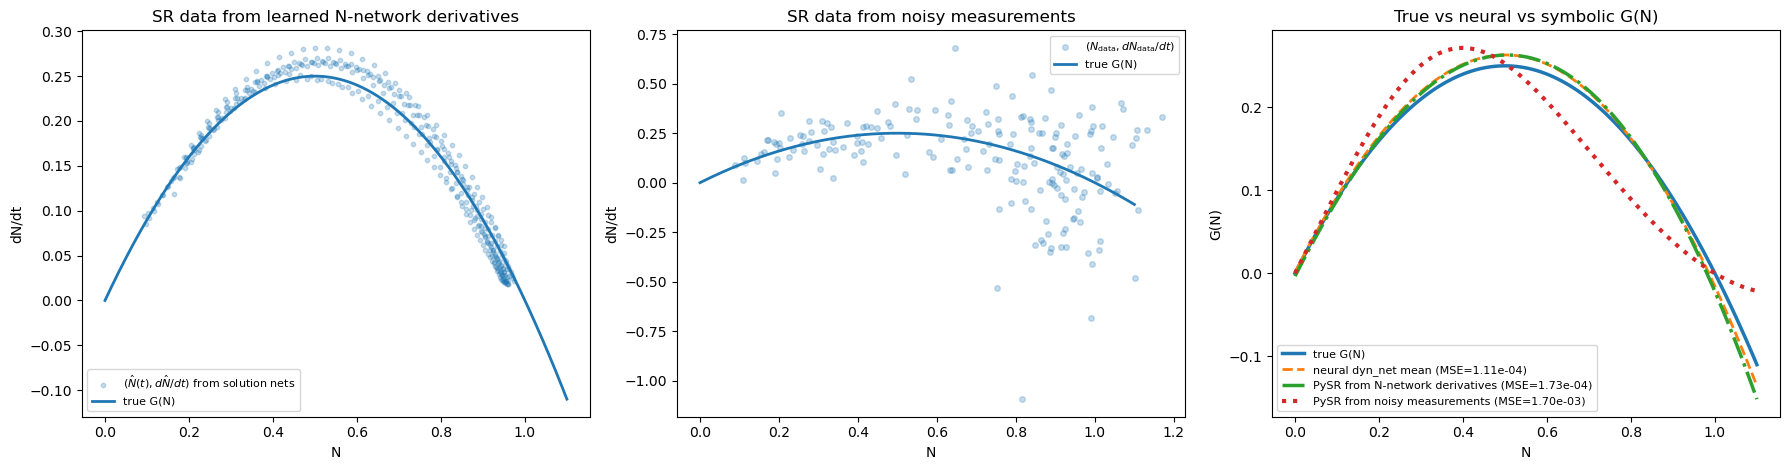


Selected equation from solution-net derivatives:
complexity                                                       9
loss                                                      0.000001
equation         x0 - (((x0 - -0.008561169) ^ 2.150666) + 0.003...
score                                                      0.68685
sympy_format     x0 - ((x0 - 1*(-0.008561169))**2.150666 + 0.00...
lambda_format    PySRFunction(X=>x0 - ((x0 - 1*(-0.008561169))*...
Name: 4, dtype: object

Selected equation from noisy measurements:
complexity                                                       9
loss                                                      0.001198
equation                    tanh((x0 + -1.3027585) * log(x0)) * x0
score                                                     0.556559
sympy_format                     x0*tanh((x0 - 1.3027585)*log(x0))
lambda_format    PySRFunction(X=>x0*tanh((x0 - 1.3027585)*log(x...
Name: 6, dtype: object
  - outputs/20260311_140514_ahqUCv/hall_of_fame.csv


In [49]:
# ============================================================
# 13. Symbolic regression (PySR) for G(N)
#     (A) using dN/dt from the learned N-network (solution nets)
#     (B) using finite-difference derivatives from noisy measurements directly
#
# Paste this AFTER your existing script.
#
# Requirement:
#   pip install pysr
#
# Notes:
# - Method A uses (N_hat(t), dN_hat/dt) from the trained solution networks.
# - Method B uses (N_data(t), dN_data/dt) where dN_data/dt is estimated by
#   finite differences on the noisy measurements.
# - Both are compared to the true G(N)=rN(1-N) via plots and MSE on N_grid.
# ============================================================

from pysr import PySRRegressor

# ------------------------------------------------------------
# Helper: rebuild the best PINN solution networks from best_states
# ------------------------------------------------------------
def rebuild_best_solnets(best_state, n_ics, hidden_dim_sol, device):
    solnet_list = []
    for i in range(n_ics):
        net = SolutionNet(hidden_dim=hidden_dim_sol).to(device)
        net.load_state_dict(best_state["sol_nets"][i])
        net.eval()
        solnet_list.append(net)
    return solnet_list


# ------------------------------------------------------------
# Helper: collect SR data from solution nets
#   X = N_hat(t), y = dN_hat/dt
# ------------------------------------------------------------
def collect_sr_data_from_solution_nets(solnet_list, t_eval):
    X_all = []
    y_all = []

    for sol_net in solnet_list:
        t_req = t_eval.clone().detach().requires_grad_(True)
        N_hat = sol_net(t_req)

        dN_dt_hat = torch.autograd.grad(
            outputs=N_hat,
            inputs=t_req,
            grad_outputs=torch.ones_like(N_hat),
            create_graph=False,
            retain_graph=False,
        )[0]

        X_all.append(N_hat.detach().cpu().numpy())
        y_all.append(dN_dt_hat.detach().cpu().numpy())

    X_all = np.vstack(X_all).reshape(-1, 1)
    y_all = np.vstack(y_all).reshape(-1)

    mask = np.isfinite(X_all[:, 0]) & np.isfinite(y_all)
    mask &= X_all[:, 0] >= 0.0

    return X_all[mask], y_all[mask]


# ------------------------------------------------------------
# Helper: collect SR data directly from noisy measurements
#   X = N_data(t), y = dN_data/dt via finite differences
# ------------------------------------------------------------
def collect_sr_data_from_noisy_measurements(y_data_all, t_obs):
    t_np = t_obs.squeeze(1).cpu().numpy()
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()   # [n_ics, numpts]

    X_all = []
    y_all = []

    for i in range(y_data_np.shape[0]):
        y_i = y_data_np[i]
        dy_dt_i = np.gradient(y_i, t_np)  # central diff interior, 1-sided endpoints

        X_all.append(y_i.reshape(-1, 1))
        y_all.append(dy_dt_i.reshape(-1))

    X_all = np.vstack(X_all).reshape(-1, 1)
    y_all = np.concatenate(y_all).reshape(-1)

    mask = np.isfinite(X_all[:, 0]) & np.isfinite(y_all)
    mask &= X_all[:, 0] >= 0.0

    return X_all[mask], y_all[mask]


# ------------------------------------------------------------
# Helper: fit PySR
# ------------------------------------------------------------
def fit_pysr_1d(X, y, niterations=200, populations=20, maxsize=18, random_state=0):
    model = PySRRegressor(
        niterations=niterations,
        populations=populations,
        population_size=50,
        maxsize=maxsize,
        model_selection="best",
        loss="loss(prediction, target) = (prediction - target)^2",
        binary_operators=["+", "-", "*", "/", "^"],
        unary_operators=["exp", "log", "sqrt", "tanh"],
        batching=False,
        turbo=True,
        progress=True,
        random_state=random_state,
        deterministic=True,
        parallelism="serial",   # <-- required with deterministic=True,
        denoise=True,           # added
        warm_start=False,
    )
    model.fit(X, y)
    return model

# ------------------------------------------------------------
# Helper: safe prediction
# ------------------------------------------------------------
def safe_predict(model, X):
    y = model.predict(X)
    y = np.asarray(y).reshape(-1)
    return y


# ------------------------------------------------------------
# Choose the best PINN split, rebuild sol_nets, and create SR datasets
# ------------------------------------------------------------
best_split_idx = int(np.argmin(best_val_losses))
best_state_for_sr = best_states[best_split_idx]

solnets_best = rebuild_best_solnets(
    best_state=best_state_for_sr,
    n_ics=n_ics,
    hidden_dim_sol=hidden_dim_sol,
    device=device,
)

# Dense time grid for the derivative-based SR dataset from the learned N-networks
t_sr_dense = torch.linspace(0.0, 5.0, 50, device=device).view(-1, 1)

X_pinn_sr, y_pinn_sr = collect_sr_data_from_solution_nets(solnets_best, t_sr_dense)
X_noisy_sr, y_noisy_sr = collect_sr_data_from_noisy_measurements(y_data_all, t_obs)

print("\nSR dataset sizes")
print("----------------")
print(f"From solution-net derivatives: X shape = {X_pinn_sr.shape}, y shape = {y_pinn_sr.shape}")
print(f"From noisy measurements       : X shape = {X_noisy_sr.shape}, y shape = {y_noisy_sr.shape}")

# ------------------------------------------------------------
# Fit PySR models
# ------------------------------------------------------------
pysr_pinn = fit_pysr_1d(
    X_pinn_sr,
    y_pinn_sr,
    niterations=40,
    populations=20,
    maxsize=10,
    random_state=123,
)

pysr_noisy = fit_pysr_1d(
    X_noisy_sr,
    y_noisy_sr,
    niterations=40,
    populations=20,
    maxsize=10,
    random_state=456,
)

print("\nBest symbolic model from solution-net derivatives")
print("--------------------------------------------------")
print(pysr_pinn)

print("\nBest symbolic model from noisy measurements")
print("-------------------------------------------")
print(pysr_noisy)

# ------------------------------------------------------------
# Evaluate both symbolic models on N_grid and compare to true G
# ------------------------------------------------------------
N_grid_np = N_grid.detach().cpu().numpy().reshape(-1, 1)
G_true_np = G_true(N_grid).detach().cpu().numpy().reshape(-1)

G_sr_pinn_np = safe_predict(pysr_pinn, N_grid_np)
G_sr_noisy_np = safe_predict(pysr_noisy, N_grid_np)

mse_sr_pinn = np.mean((G_sr_pinn_np - G_true_np) ** 2)
mse_sr_noisy = np.mean((G_sr_noisy_np - G_true_np) ** 2)
mse_nn = np.mean((rhs_mean - G_true_np) ** 2)

print("\nMSE on N_grid against true G")
print("----------------------------")
print(f"Neural dyn_net mean MSE           : {mse_nn:.6e}")
print(f"PySR from solution-net dN/dt MSE  : {mse_sr_pinn:.6e}")
print(f"PySR from noisy finite-diff MSE   : {mse_sr_noisy:.6e}")

# ------------------------------------------------------------
# Plot datasets used by SR and final recovered G(N)
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# Dataset from solution nets
axes[0].scatter(
    X_pinn_sr[:, 0],
    y_pinn_sr,
    s=10,
    alpha=0.25,
    label=r"$(\hat N(t), d\hat N/dt)$ from solution nets",
)
axes[0].plot(
    N_grid_np[:, 0],
    G_true_np,
    linewidth=2,
    label="true G(N)",
)
axes[0].set_xlabel("N")
axes[0].set_ylabel("dN/dt")
axes[0].set_title("SR data from learned N-network derivatives")
axes[0].legend(fontsize=8)

# Dataset from noisy measurements
axes[1].scatter(
    X_noisy_sr[:, 0],
    y_noisy_sr,
    s=16,
    alpha=0.25,
    label=r"$(N_{\mathrm{data}}, dN_{\mathrm{data}}/dt)$",
)
axes[1].plot(
    N_grid_np[:, 0],
    G_true_np,
    linewidth=2,
    label="true G(N)",
)
axes[1].set_xlabel("N")
axes[1].set_ylabel("dN/dt")
axes[1].set_title("SR data from noisy measurements")
axes[1].legend(fontsize=8)

# Final comparison
axes[2].plot(
    N_grid_np[:, 0],
    G_true_np,
    linewidth=2.5,
    label="true G(N)",
)
axes[2].plot(
    N_grid_np[:, 0],
    rhs_mean,
    "--",
    linewidth=2,
    label=f"neural dyn_net mean (MSE={mse_nn:.2e})",
)
axes[2].plot(
    N_grid_np[:, 0],
    G_sr_pinn_np,
    "-.",
    linewidth=2.5,
    label=f"PySR from N-network derivatives (MSE={mse_sr_pinn:.2e})",
)
axes[2].plot(
    N_grid_np[:, 0],
    G_sr_noisy_np,
    ":",
    linewidth=3.0,
    label=f"PySR from noisy measurements (MSE={mse_sr_noisy:.2e})",
)
axes[2].set_xlabel("N")
axes[2].set_ylabel("G(N)")
axes[2].set_title("True vs neural vs symbolic G(N)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Optional: print the selected equations more explicitly
# ------------------------------------------------------------
try:
    print("\nSelected equation from solution-net derivatives:")
    print(pysr_pinn.get_best())

    print("\nSelected equation from noisy measurements:")
    print(pysr_noisy.get_best())
except Exception as e:
    print("\nCould not print get_best() details.")
    print(f"Reason: {e}")


Starting PINN split 1/1
Dynamics init seed for split 1: 10000
Solution init seeds for split 1: [20000, 20001, 20002, 20003]
PINN | Split  1/1 | Epoch     1/3000 | Train Total: 7.042563e-01 | Train Data: 7.015274e-01 | Train Phys: 2.728856e-03 | Train Anchor: 2.909430e-02 | Val Total: 5.831551e-01 | Val Data: 5.807477e-01 | Val Phys: 2.407355e-03
PINN | Split  1/1 | Epoch   500/3000 | Train Total: 4.760143e-03 | Train Data: 4.357913e-03 | Train Phys: 4.022307e-04 | Train Anchor: 1.672614e-05 | Val Total: 3.909421e-03 | Val Data: 3.529363e-03 | Val Phys: 3.800572e-04
PINN | Split  1/1 | Epoch  1000/3000 | Train Total: 4.444189e-03 | Train Data: 4.154616e-03 | Train Phys: 2.895735e-04 | Train Anchor: 1.639678e-05 | Val Total: 3.502682e-03 | Val Data: 3.261924e-03 | Val Phys: 2.407571e-04
PINN | Split  1/1 | Epoch  1500/3000 | Train Total: 4.303767e-03 | Train Data: 4.050747e-03 | Train Phys: 2.530200e-04 | Train Anchor: 1.375969e-05 | Val Total: 3.631203e-03 | Val Data: 3.336842e-03 | Va

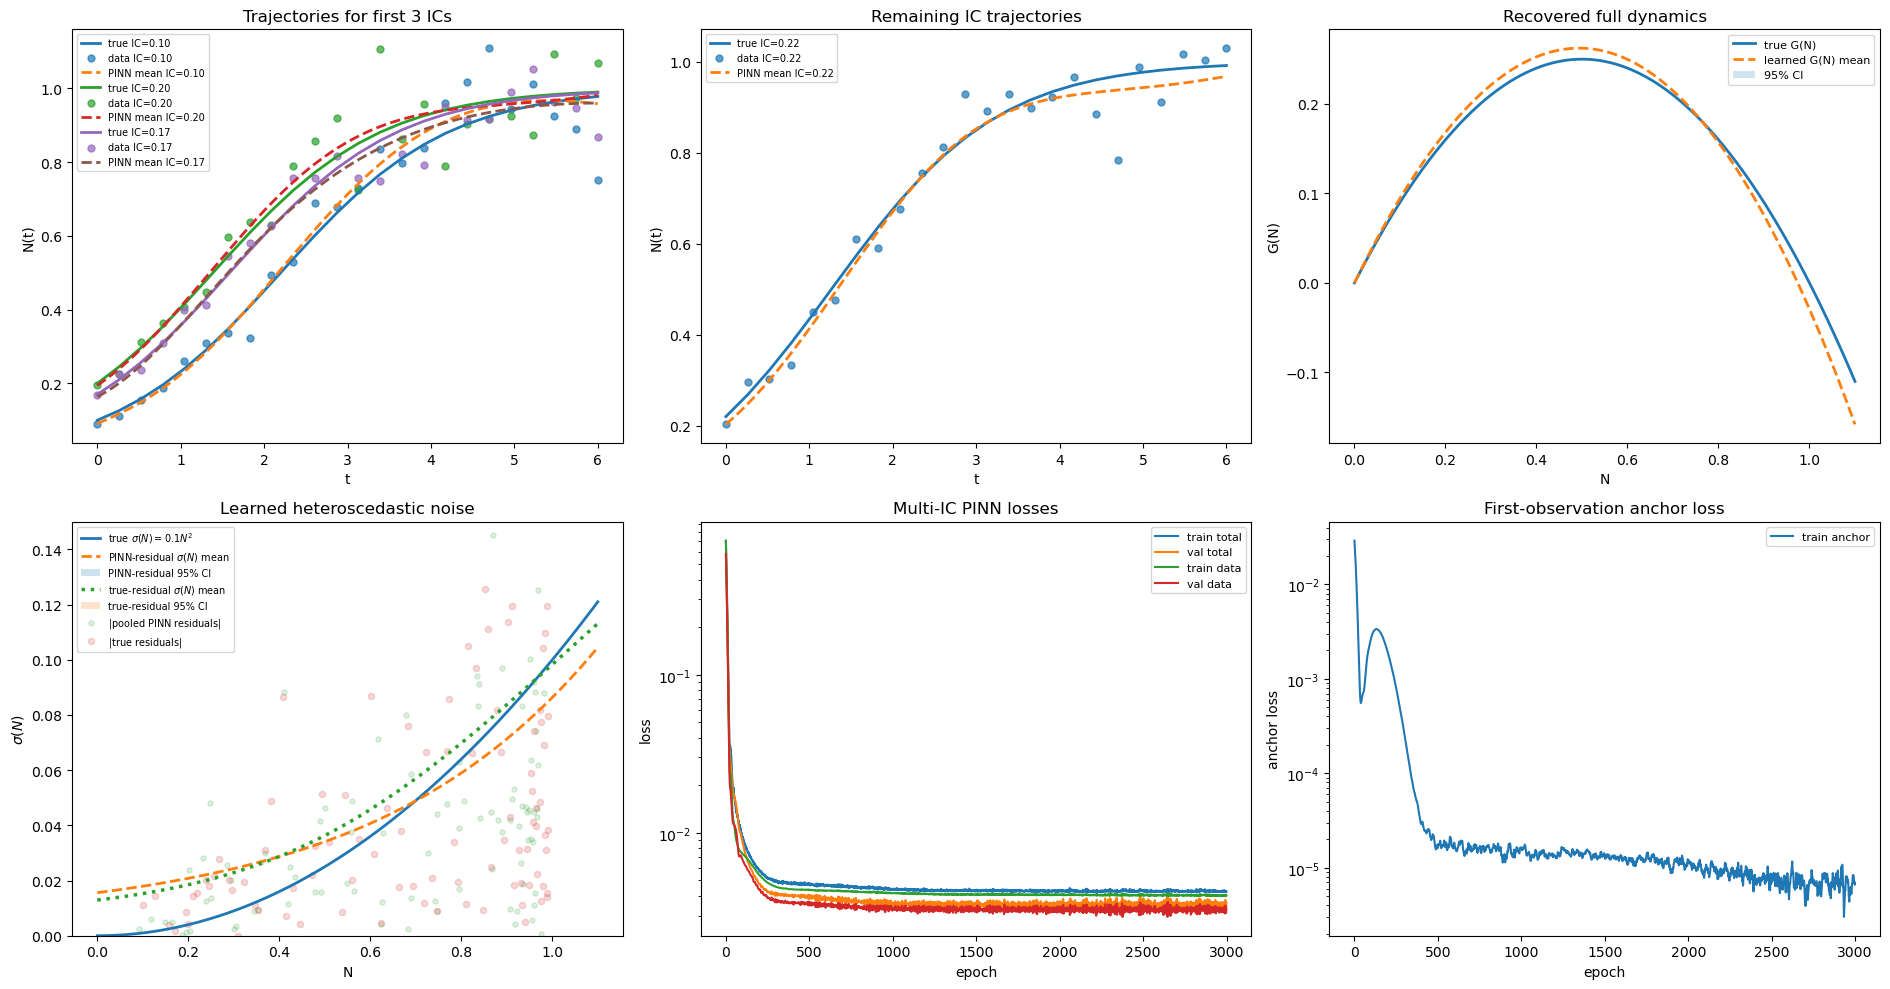

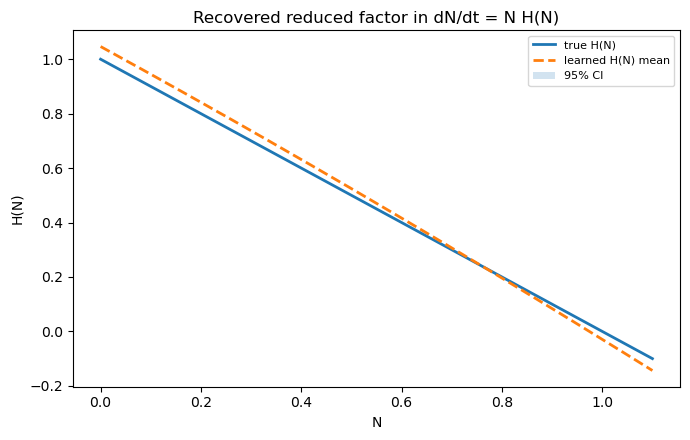

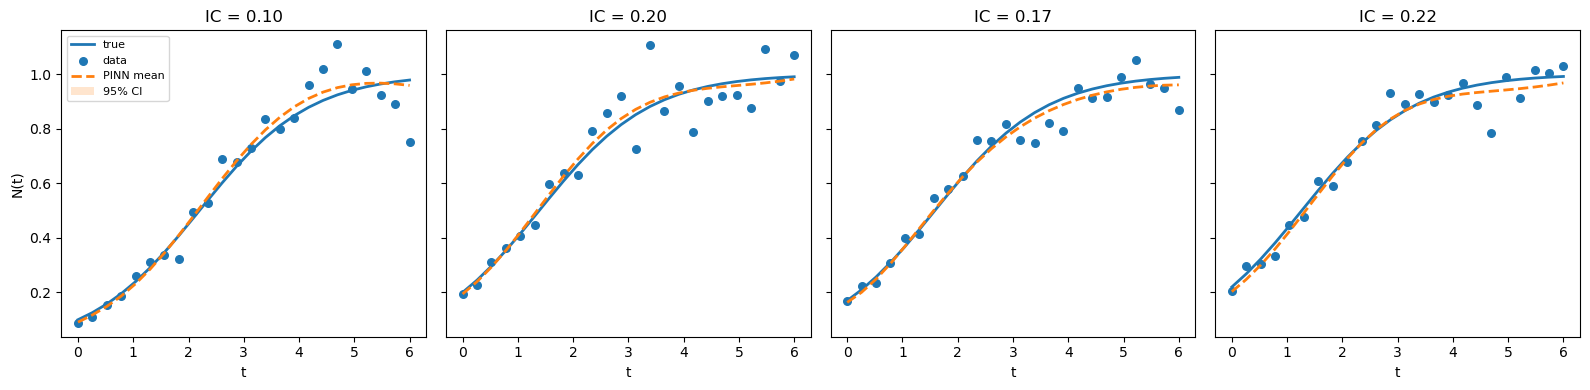

/var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/ipykernel_9670/3377844785.py:775: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[0].set_yscale("log")


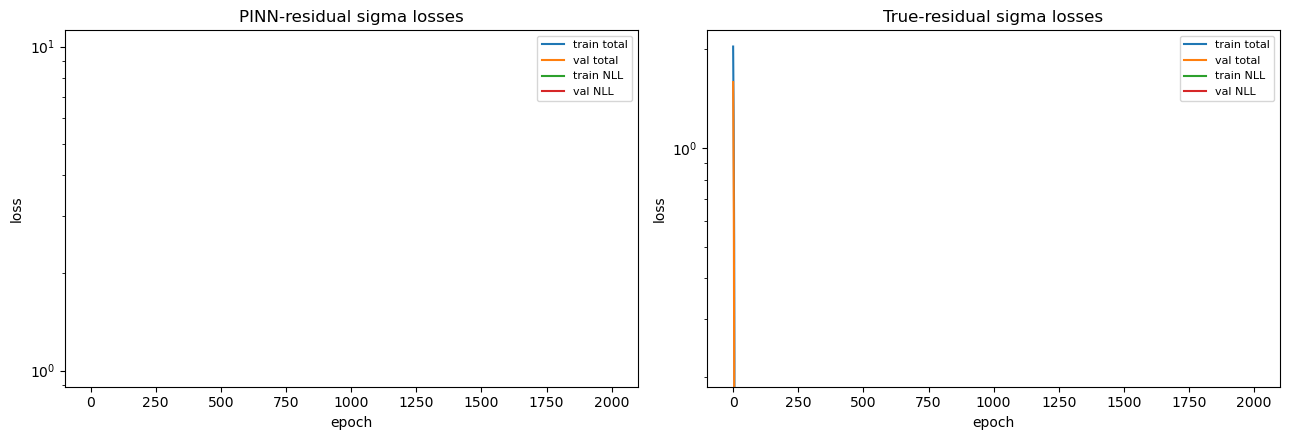


Multi-IC PINN summary
---------------------
Number of trajectories / ICs: 4
Synthetic IC values used to generate data: [0.1, 0.2, 0.17, 0.22]
Number of PINN splits: 1
Validation fraction: 0.2
Model-selection criterion: validation loss
Mean best selection loss: 3.181050e-03
Std  best selection loss: N/A (only one split)
Mean best epoch: 2646.00
Std  best epoch: N/A (only one split)
Anchor weight lambda_anchor: 0.000
Dynamics model assumption: dN/dt = N * H(N), with dyn_net learning H(N)

Initialization summary by split
-------------------------------
Split 1: dyn_init_seed=10000, sol_init_seeds=[20000, 20001, 20002, 20003], selection_criterion=val

PINN-residual sigma summary
---------------------------
Number of sigma repeats: 1
Mean best selection loss: -4.920988e+00
Std  best selection loss: N/A (only one repeat)
Mean best epoch: 1999.00
Std  best epoch: N/A (only one repeat)

True-residual sigma summary
---------------------------
Number of sigma repeats: 1
Mean best selection loss

In [37]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


def H_true(N):
    return r_true * (1.0 - N)

def G_true(N):
    return N * H_true(N)



with torch.no_grad():
    G_grid_true = G_true(N_grid)
    H_grid_true = H_true(N_grid)
    sigma_true_grid = 0.1 * N_grid**2
# ============================================================
# 4. Helper functions
# ============================================================

def pinn_physics_residual(sol_net, dyn_net, t_col):
    """
    Physics model:
        dN/dt = N * H(N)
    where dyn_net(N) approximates H(N).
    """
    N_pred_col = sol_net(t_col)
    dN_dt = torch.autograd.grad(
        outputs=N_pred_col,
        inputs=t_col,
        grad_outputs=torch.ones_like(N_pred_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    h_pred = dyn_net(N_pred_col)
    rhs_pred = N_pred_col * h_pred
    phys_res = dN_dt - rhs_pred
    return N_pred_col, dN_dt, h_pred, rhs_pred, phys_res



# ============================================================
# 5. Multi-IC PINN fit
# ============================================================
n_col = 1000
t_col_base = torch.linspace(0.0, 6.0, n_col, device=device).view(-1, 1)

n_epochs = 3000
n_splits = 1
print_every = 500
batch_obs = 24 * 4 * n_ics
batch_col = 100

val_fraction = 0.2
n_obs = t_obs.shape[0]
use_validation = val_fraction > 0.0 and n_obs > 1

if use_validation:
    n_val = int(round(val_fraction * n_obs))
    n_val = max(1, min(n_val, n_obs - 1))
else:
    n_val = 0
n_train = n_obs - n_val

lambda_phys = 1.0
lambda_anchor = 0.0
learning_rate = 1e-3
hidden_dim_sol = 32
hidden_dim_dyn = 32

data_split_seed_base = 1000
dyn_init_seed_base = 10000
sol_init_seed_base = 20000

train_total_histories = []
train_data_histories = []
train_phys_histories = []
train_anchor_histories = []

val_total_histories = []
val_data_histories = []
val_phys_histories = []

traj_histories = []
rhs_histories = []   # stores learned full G(N) = N * H(N)
h_histories = []     # stores learned reduced factor H(N)
obs_fit_histories = []

best_val_losses = []
best_epochs = []
best_states = []

for split in range(n_splits):
    print(f"\n{'=' * 90}")
    print(f"Starting PINN split {split + 1}/{n_splits}")
    print(f"{'=' * 90}")

    g = torch.Generator(device=device)
    g.manual_seed(data_split_seed_base + split)

    perm = torch.randperm(n_obs, generator=g, device=device)
    train_idx = perm[:n_train].sort().values

    if use_validation:
        val_idx = perm[n_train:].sort().values
    else:
        val_idx = torch.empty(0, dtype=torch.long, device=device)

    torch.manual_seed(dyn_init_seed_base + split)
    np.random.seed(dyn_init_seed_base + split)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)

    sol_net_list = []
    sol_init_seeds_this_split = []
    for i in range(n_ics):
        init_seed = sol_init_seed_base + 1000 * split + i
        sol_init_seeds_this_split.append(init_seed)
        torch.manual_seed(init_seed)
        np.random.seed(init_seed)
        sol_net_list.append(SolutionNet(hidden_dim=hidden_dim_sol).to(device))

    sol_nets = nn.ModuleList(sol_net_list)

    print(f"Dynamics init seed for split {split + 1}: {dyn_init_seed_base + split}")
    print(f"Solution init seeds for split {split + 1}: {sol_init_seeds_this_split}")

    optimizer = torch.optim.Adam(
        list(dyn_net.parameters()) + list(sol_nets.parameters()),
        lr=learning_rate,
    )

    train_total_history = []
    train_data_history = []
    train_phys_history = []
    train_anchor_history = []

    val_total_history = []
    val_data_history = []
    val_phys_history = []

    best_criterion = float("inf")
    best_epoch = -1
    best_state = None

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        total_data_loss = 0.0
        total_phys_loss = 0.0
        total_anchor_loss = 0.0

        for i in range(n_ics):
            sol_net = sol_nets[i]

            obs_sel = train_idx[torch.randperm(len(train_idx), device=device)[:batch_obs]]
            t_train = t_obs[obs_sel]
            y_train = y_data_all[i][obs_sel]

            N_pred_train = sol_net(t_train)
            data_loss = torch.mean((N_pred_train - y_train) ** 2)

            t_col = 6.0 * torch.rand(batch_col, 1, device=device)
            t_col.requires_grad_(True)
            _, _, _, _, phys_res = pinn_physics_residual(sol_net, dyn_net, t_col)
            phys_loss = torch.mean(phys_res ** 2)

            t0_obs = t_obs[0:1]
            y0_obs = y_data_all[i][0:1]
            N0_pred = sol_net(t0_obs)
            anchor_loss = torch.mean((N0_pred - y0_obs) ** 2)

            total_data_loss += data_loss
            total_phys_loss += phys_loss
            total_anchor_loss += anchor_loss

        total_data_loss /= n_ics
        total_phys_loss /= n_ics
        total_anchor_loss /= n_ics

        train_loss = total_data_loss + lambda_phys * total_phys_loss + lambda_anchor * total_anchor_loss
        train_loss.backward()
        optimizer.step()

        if use_validation:
            with torch.no_grad():
                total_val_data_loss = 0.0
                for i in range(n_ics):
                    sol_net = sol_nets[i]
                    t_val = t_obs[val_idx]
                    y_val = y_data_all[i][val_idx]
                    N_pred_val = sol_net(t_val)
                    total_val_data_loss = total_val_data_loss + torch.mean((N_pred_val - y_val) ** 2)

                total_val_data_loss = total_val_data_loss / n_ics

            total_val_phys_loss = 0.0
            for i in range(n_ics):
                sol_net = sol_nets[i]
                t_col_val = t_col_base.clone().detach().requires_grad_(True)
                _, _, _, _, val_phys_res = pinn_physics_residual(sol_net, dyn_net, t_col_val)
                total_val_phys_loss = total_val_phys_loss + torch.mean(val_phys_res ** 2)

            total_val_phys_loss = total_val_phys_loss / n_ics
            val_loss = total_val_data_loss + lambda_phys * total_val_phys_loss

            criterion_value = val_loss.item()
            criterion_name = "val"

            val_total_item = val_loss.item()
            val_data_item = total_val_data_loss.item()
            val_phys_item = total_val_phys_loss.item()
        else:
            criterion_value = train_loss.item()
            criterion_name = "train"

            val_total_item = np.nan
            val_data_item = np.nan
            val_phys_item = np.nan

        train_total_history.append(train_loss.item())
        train_data_history.append(total_data_loss.item())
        train_phys_history.append(total_phys_loss.item())
        train_anchor_history.append(total_anchor_loss.item())

        val_total_history.append(val_total_item)
        val_data_history.append(val_data_item)
        val_phys_history.append(val_phys_item)

        if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
            if use_validation:
                print(
                    f"PINN | Split {split + 1:2d}/{n_splits} | "
                    f"Epoch {epoch + 1:5d}/{n_epochs} | "
                    f"Train Total: {train_loss.item():.6e} | "
                    f"Train Data: {total_data_loss.item():.6e} | "
                    f"Train Phys: {total_phys_loss.item():.6e} | "
                    f"Train Anchor: {total_anchor_loss.item():.6e} | "
                    f"Val Total: {val_total_item:.6e} | "
                    f"Val Data: {val_data_item:.6e} | "
                    f"Val Phys: {val_phys_item:.6e}"
                )
            else:
                print(
                    f"PINN | Split {split + 1:2d}/{n_splits} | "
                    f"Epoch {epoch + 1:5d}/{n_epochs} | "
                    f"Train Total: {train_loss.item():.6e} | "
                    f"Train Data: {total_data_loss.item():.6e} | "
                    f"Train Phys: {total_phys_loss.item():.6e} | "
                    f"Train Anchor: {total_anchor_loss.item():.6e} | "
                    f"Val Total: N/A | Val Data: N/A | Val Phys: N/A | "
                    f"Best-model criterion: training loss"
                )

        if criterion_value < best_criterion:
            best_criterion = criterion_value
            best_epoch = epoch
            best_state = {
                "dyn_net": copy.deepcopy(dyn_net.state_dict()),
                "sol_nets": [copy.deepcopy(sol_net.state_dict()) for sol_net in sol_nets],
                "dyn_init_seed": dyn_init_seed_base + split,
                "sol_init_seeds": sol_init_seeds_this_split.copy(),
                "train_idx": train_idx.clone(),
                "val_idx": val_idx.clone(),
                "selection_criterion": criterion_name,
            }

    if use_validation:
        print(
            f"Finished PINN split {split + 1:2d}/{n_splits} | "
            f"Best epoch = {best_epoch:5d} | Best val loss = {best_criterion:.6e}"
        )
    else:
        print(
            f"Finished PINN split {split + 1:2d}/{n_splits} | "
            f"Best epoch = {best_epoch:5d} | Best train loss = {best_criterion:.6e}"
        )

    dyn_net.load_state_dict(best_state["dyn_net"])
    for i in range(n_ics):
        sol_nets[i].load_state_dict(best_state["sol_nets"][i])

    dyn_net.eval()
    for sol_net in sol_nets:
        sol_net.eval()

    with torch.no_grad():
        trajs_this_split = []
        obs_fits_this_split = []

        for i in range(n_ics):
            trajs_this_split.append(sol_nets[i](t_plot).squeeze(1).cpu().numpy())
            obs_fits_this_split.append(sol_nets[i](t_obs).squeeze(1).cpu().numpy())

        H_grid_learned = dyn_net(N_grid).squeeze(1).cpu().numpy()
        G_grid_learned = (N_grid.squeeze(1).cpu().numpy()) * H_grid_learned

    train_total_histories.append(train_total_history)
    train_data_histories.append(train_data_history)
    train_phys_histories.append(train_phys_history)
    train_anchor_histories.append(train_anchor_history)

    val_total_histories.append(val_total_history)
    val_data_histories.append(val_data_history)
    val_phys_histories.append(val_phys_history)

    traj_histories.append(np.array(trajs_this_split))
    obs_fit_histories.append(np.array(obs_fits_this_split))
    rhs_histories.append(G_grid_learned)
    h_histories.append(H_grid_learned)

    best_val_losses.append(best_criterion)
    best_epochs.append(best_epoch)
    best_states.append(best_state)

train_total_histories = np.array(train_total_histories)
train_data_histories = np.array(train_data_histories)
train_phys_histories = np.array(train_phys_histories)
train_anchor_histories = np.array(train_anchor_histories)

val_total_histories = np.array(val_total_histories)
val_data_histories = np.array(val_data_histories)
val_phys_histories = np.array(val_phys_histories)

traj_histories = np.array(traj_histories)
obs_fit_histories = np.array(obs_fit_histories)
rhs_histories = np.array(rhs_histories)
h_histories = np.array(h_histories)

rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)
h_mean, h_lo, h_hi = mean_and_ci(h_histories)

traj_mean_per_ic = []
traj_lo_per_ic = []
traj_hi_per_ic = []

obs_fit_mean_per_ic = []
obs_fit_lo_per_ic = []
obs_fit_hi_per_ic = []

for i in range(n_ics):
    m, lo, hi = mean_and_ci(traj_histories[:, i, :])
    traj_mean_per_ic.append(m)
    traj_lo_per_ic.append(lo)
    traj_hi_per_ic.append(hi)

    m, lo, hi = mean_and_ci(obs_fit_histories[:, i, :])
    obs_fit_mean_per_ic.append(m)
    obs_fit_lo_per_ic.append(lo)
    obs_fit_hi_per_ic.append(hi)


# ============================================================
# 6. Learn sigma(N) from pooled multi-IC PINN residuals
# ============================================================
with torch.no_grad():
    y_rep = y_data_all.squeeze(-1).cpu().numpy()[None, :, :]
    resid_pinn_all_np = y_rep - obs_fit_histories

    N_pinn_sigma_all_np = obs_fit_histories.reshape(-1, 1)
    resid_pinn_sigma_all_np = resid_pinn_all_np.reshape(-1, 1)

    mask = N_pinn_sigma_all_np.squeeze() > 0.0
    N_pinn_sigma_all_np = N_pinn_sigma_all_np[mask]
    resid_pinn_sigma_all_np = resid_pinn_sigma_all_np[mask]

N_pinn_sigma_all = torch.tensor(N_pinn_sigma_all_np, dtype=torch.float32, device=device)
resid_pinn_sigma_all = torch.tensor(resid_pinn_sigma_all_np, dtype=torch.float32, device=device)

N_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_pinn_sigma_all.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_pinn_results = fit_sigma_repeated(
    N_all=N_pinn_sigma_all,
    resid_all=resid_pinn_sigma_all,
    N_eval_grid=N_grid,
    N_col_base=N_sigma_col_base,
    n_repeats=1,
    val_fraction=0.4,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="PINN-sigma",
    print_every=250,
)

sigma_pinn_mean, sigma_pinn_lo, sigma_pinn_hi = mean_and_ci(
    sigma_pinn_results["curve_histories"]
)


# ============================================================
# 7. Learn sigma_truefit(N) from true residuals
# ============================================================
with torch.no_grad():
    N_true_sigma_np = y_true_all.squeeze(-1).cpu().numpy().reshape(-1, 1)
    resid_true_sigma_np = (y_data_all - y_true_all).squeeze(-1).cpu().numpy().reshape(-1, 1)

    mask_true = N_true_sigma_np.squeeze() > 0.0
    N_true_sigma_np = N_true_sigma_np[mask_true]
    resid_true_sigma_np = resid_true_sigma_np[mask_true]

N_true_sigma = torch.tensor(N_true_sigma_np, dtype=torch.float32, device=device)
resid_true_sigma = torch.tensor(resid_true_sigma_np, dtype=torch.float32, device=device)

N_true_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_true_sigma.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_truefit_results = fit_sigma_repeated(
    N_all=N_true_sigma,
    resid_all=resid_true_sigma,
    N_eval_grid=N_grid,
    N_col_base=N_true_sigma_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=9000,
    seed_offset_model=11000,
    label="TRUE-sigma",
    print_every=250,
)

sigma_truefit_mean, sigma_truefit_lo, sigma_truefit_hi = mean_and_ci(
    sigma_truefit_results["curve_histories"]
)


# ============================================================
# 8. Residuals across all ICs using mean PINN fit
# ============================================================
with torch.no_grad():
    obs_fit_mean_all = np.array(obs_fit_mean_per_ic)
    y_true_np = y_true_all.squeeze(-1).cpu().numpy()
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()

    residuals_all = y_data_np - obs_fit_mean_all
    N_fit_all = obs_fit_mean_all.reshape(-1, 1)
    residuals_flat = residuals_all.reshape(-1, 1)

    mask = N_fit_all.squeeze() > 0.0
    N_fit_all = N_fit_all[mask]
    residuals_flat = residuals_flat[mask]


# ============================================================
# 9. Plots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

# ------------------------------------------------------------
# Trajectories
# ------------------------------------------------------------
for i in range(min(3, n_ics)):
    axes[0, 0].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 0].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 0].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"PINN mean IC={N0_list[i]:.2f}",
    )
    axes[0, 0].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("N(t)")
axes[0, 0].set_title("Trajectories for first 3 ICs")
axes[0, 0].legend(fontsize=7)

# ------------------------------------------------------------
# Remaining ICs
# ------------------------------------------------------------
for i in range(3, n_ics):
    axes[0, 1].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 1].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 1].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"PINN mean IC={N0_list[i]:.2f}",
    )
    axes[0, 1].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 1].set_xlabel("t")
axes[0, 1].set_ylabel("N(t)")
axes[0, 1].set_title("Remaining IC trajectories")
axes[0, 1].legend(fontsize=7)

# ------------------------------------------------------------
# Recovered full dynamics G(N) = N * H(N)
# ------------------------------------------------------------
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    G_grid_true.squeeze(1).cpu().numpy(),
    label="true G(N)",
    linewidth=2,
)
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="learned G(N) mean",
)
axes[0, 2].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.20,
    label="95% CI",
)
axes[0, 2].set_xlabel("N")
axes[0, 2].set_ylabel("G(N)")
axes[0, 2].set_title("Recovered full dynamics")
axes[0, 2].legend(fontsize=8)

# ------------------------------------------------------------
# Learned sigma(N)
# ------------------------------------------------------------
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_true_grid.squeeze(1).cpu().numpy(),
    linewidth=2,
    label=r"true $\sigma(N)=0.1N^2$",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=r"PINN-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_truefit_mean,
    ":",
    linewidth=2.5,
    label=r"true-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI",
)
axes[1, 0].scatter(
    N_pinn_sigma_all.cpu().numpy().squeeze(),
    np.abs(resid_pinn_sigma_all.cpu().numpy().squeeze()),
    s=14,
    alpha=0.16,
    label=r"$|$pooled PINN residuals$|$",
)
axes[1, 0].scatter(
    N_true_sigma.cpu().numpy().squeeze(),
    np.abs(resid_true_sigma.cpu().numpy().squeeze()),
    s=20,
    alpha=0.18,
    label=r"$|$true residuals$|$",
)
axes[1, 0].set_xlabel("N")
axes[1, 0].set_ylabel(r"$\sigma(N)$")
axes[1, 0].set_title("Learned heteroscedastic noise")
axes[1, 0].legend(fontsize=7)
axes[1, 0].set_ylim(0, 0.15)

# ------------------------------------------------------------
# PINN losses
# ------------------------------------------------------------
epochs_init = np.arange(n_epochs)

train_total_mean, train_total_lo, train_total_hi = mean_and_ci(train_total_histories)
val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)
val_data_mean, val_data_lo, val_data_hi = mean_and_ci(val_data_histories)

axes[1, 1].plot(epochs_init, train_total_mean, label="train total")
axes[1, 1].fill_between(epochs_init, train_total_lo, train_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_total_mean, label="val total")
axes[1, 1].fill_between(epochs_init, val_total_lo, val_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, train_data_mean, label="train data")
axes[1, 1].fill_between(epochs_init, train_data_lo, train_data_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_data_mean, label="val data")
axes[1, 1].fill_between(epochs_init, val_data_lo, val_data_hi, alpha=0.2)
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylabel("loss")
axes[1, 1].set_title("Multi-IC PINN losses")
axes[1, 1].legend(fontsize=8)

# ------------------------------------------------------------
# Anchor loss
# ------------------------------------------------------------
train_anchor_mean, train_anchor_lo, train_anchor_hi = mean_and_ci(train_anchor_histories)
axes[1, 2].plot(epochs_init, train_anchor_mean, label="train anchor")
axes[1, 2].fill_between(epochs_init, train_anchor_lo, train_anchor_hi, alpha=0.2)
axes[1, 2].set_yscale("log")
axes[1, 2].set_xlabel("epoch")
axes[1, 2].set_ylabel("anchor loss")
axes[1, 2].set_title("First-observation anchor loss")
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Extra plot: recovered reduced factor H(N)
# ------------------------------------------------------------
plt.figure(figsize=(7, 4.5))
plt.plot(
    N_grid.cpu().numpy(),
    H_grid_true.squeeze(1).cpu().numpy(),
    label="true H(N)",
    linewidth=2,
)
plt.plot(
    N_grid.cpu().numpy(),
    h_mean,
    "--",
    linewidth=2,
    label="learned H(N) mean",
)
plt.fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    h_lo,
    h_hi,
    alpha=0.20,
    label="95% CI",
)
plt.xlabel("N")
plt.ylabel("H(N)")
plt.title("Recovered reduced factor in dN/dt = N H(N)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 10. Observation-time comparison
# ============================================================
fig, axs = plt.subplots(1, n_ics, figsize=(4 * n_ics, 4), sharey=True)

if n_ics == 1:
    axs = [axs]

for i in range(n_ics):
    axs[i].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        label="true",
        linewidth=2,
    )
    axs[i].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        label="data",
        s=30,
    )
    axs[i].plot(
        t_obs.cpu().numpy(),
        obs_fit_mean_per_ic[i],
        "--",
        linewidth=2,
        label="PINN mean",
    )
    axs[i].fill_between(
        t_obs.squeeze(1).cpu().numpy(),
        obs_fit_lo_per_ic[i],
        obs_fit_hi_per_ic[i],
        alpha=0.20,
        label="95% CI",
    )
    axs[i].set_title(f"IC = {N0_list[i]:.2f}")
    axs[i].set_xlabel("t")

axs[0].set_ylabel("N(t)")
axs[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 11. Sigma training diagnostics
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

epochs_sigma = np.arange(sigma_pinn_results["train_total_histories"].shape[1])

sp_train_total_mean, sp_train_total_lo, sp_train_total_hi = mean_and_ci(
    sigma_pinn_results["train_total_histories"]
)
sp_val_total_mean, sp_val_total_lo, sp_val_total_hi = mean_and_ci(
    sigma_pinn_results["val_total_histories"]
)
sp_train_nll_mean, sp_train_nll_lo, sp_train_nll_hi = mean_and_ci(
    sigma_pinn_results["train_nll_histories"]
)
sp_val_nll_mean, sp_val_nll_lo, sp_val_nll_hi = mean_and_ci(
    sigma_pinn_results["val_nll_histories"]
)

axes[0].plot(epochs_sigma, sp_train_total_mean, label="train total")
axes[0].fill_between(epochs_sigma, sp_train_total_lo, sp_train_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_total_mean, label="val total")
axes[0].fill_between(epochs_sigma, sp_val_total_lo, sp_val_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_train_nll_mean, label="train NLL")
axes[0].fill_between(epochs_sigma, sp_train_nll_lo, sp_train_nll_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_nll_mean, label="val NLL")
axes[0].fill_between(epochs_sigma, sp_val_nll_lo, sp_val_nll_hi, alpha=0.2)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("PINN-residual sigma losses")
axes[0].legend(fontsize=8)

st_train_total_mean, st_train_total_lo, st_train_total_hi = mean_and_ci(
    sigma_truefit_results["train_total_histories"]
)
st_val_total_mean, st_val_total_lo, st_val_total_hi = mean_and_ci(
    sigma_truefit_results["val_total_histories"]
)
st_train_nll_mean, st_train_nll_lo, st_train_nll_hi = mean_and_ci(
    sigma_truefit_results["train_nll_histories"]
)
st_val_nll_mean, st_val_nll_lo, st_val_nll_hi = mean_and_ci(
    sigma_truefit_results["val_nll_histories"]
)

axes[1].plot(epochs_sigma, st_train_total_mean, label="train total")
axes[1].fill_between(epochs_sigma, st_train_total_lo, st_train_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_total_mean, label="val total")
axes[1].fill_between(epochs_sigma, st_val_total_lo, st_val_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_train_nll_mean, label="train NLL")
axes[1].fill_between(epochs_sigma, st_train_nll_lo, st_train_nll_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_nll_mean, label="val NLL")
axes[1].fill_between(epochs_sigma, st_val_nll_lo, st_val_nll_hi, alpha=0.2)
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("True-residual sigma losses")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 12. Summary
# ============================================================
print("\nMulti-IC PINN summary")
print("---------------------")
print(f"Number of trajectories / ICs: {n_ics}")
print(f"Synthetic IC values used to generate data: {N0_list}")
print(f"Number of PINN splits: {n_splits}")
print(f"Validation fraction: {val_fraction}")
print(f"Model-selection criterion: {'validation loss' if use_validation else 'training loss'}")
print(f"Mean best selection loss: {np.mean(best_val_losses):.6e}")
if len(best_val_losses) > 1:
    print(f"Std  best selection loss: {np.std(best_val_losses, ddof=1):.6e}")
else:
    print("Std  best selection loss: N/A (only one split)")
print(f"Mean best epoch: {np.mean(best_epochs):.2f}")
if len(best_epochs) > 1:
    print(f"Std  best epoch: {np.std(best_epochs, ddof=1):.2f}")
else:
    print("Std  best epoch: N/A (only one split)")
print(f"Anchor weight lambda_anchor: {lambda_anchor:.3f}")
print("Dynamics model assumption: dN/dt = N * H(N), with dyn_net learning H(N)")

print("\nInitialization summary by split")
print("-------------------------------")
for split, st in enumerate(best_states, start=1):
    print(
        f"Split {split}: dyn_init_seed={st['dyn_init_seed']}, "
        f"sol_init_seeds={st['sol_init_seeds']}, "
        f"selection_criterion={st['selection_criterion']}"
    )

print("\nPINN-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_pinn_results['best_val_losses'])}")
print(f"Mean best selection loss: {sigma_pinn_results['best_val_losses'].mean():.6e}")
if len(sigma_pinn_results['best_val_losses']) > 1:
    print(f"Std  best selection loss: {sigma_pinn_results['best_val_losses'].std(ddof=1):.6e}")
else:
    print("Std  best selection loss: N/A (only one repeat)")
print(f"Mean best epoch: {sigma_pinn_results['best_epochs'].mean():.2f}")
if len(sigma_pinn_results['best_epochs']) > 1:
    print(f"Std  best epoch: {sigma_pinn_results['best_epochs'].std(ddof=1):.2f}")
else:
    print("Std  best epoch: N/A (only one repeat)")

print("\nTrue-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_truefit_results['best_val_losses'])}")
print(f"Mean best selection loss: {sigma_truefit_results['best_val_losses'].mean():.6e}")
if len(sigma_truefit_results['best_val_losses']) > 1:
    print(f"Std  best selection loss: {sigma_truefit_results['best_val_losses'].std(ddof=1):.6e}")
else:
    print("Std  best selection loss: N/A (only one repeat)")
print(f"Mean best epoch: {sigma_truefit_results['best_epochs'].mean():.2f}")
if len(sigma_truefit_results['best_epochs']) > 1:
    print(f"Std  best epoch: {sigma_truefit_results['best_epochs'].std(ddof=1):.2f}")
else:
    print("Std  best epoch: N/A (only one repeat)")

print("\nObserved time points: true vs data vs PINN mean")
for i in range(n_ics):
    print(f"\nTrajectory {i + 1} (synthetic IC used to generate data = {N0_list[i]:.2f})")
    for ti, yt, yd, mu in zip(
        t_obs.squeeze(1).cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        obs_fit_mean_per_ic[i],
    ):
        print(
            f"t = {ti:6.3f} | true = {yt:8.5f} | data = {yd:8.5f} | PINN = {mu:8.5f}"
        )


SR dataset sizes for H(N)
-------------------------
From solution-net derivatives: X shape = (400, 1), y shape = (400,)
From noisy measurements      : X shape = (96, 1), y shape = (96,)


/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:1017: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/sklearn/gaussian_process/_gpr.py:659: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:89: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}

───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           8.605e-02  1.594e+01  y = 0.30564
3           5.806e-04  2.499e+00  y = 1.0027 - x₀
5           1.210e-04  7.843e-01  y = (0.98034 - x₀) * 1.0789
7           1.210e-04  3.278e-07  y = ((-0.1086 - x₀) + 1.0889) * 1.0789
───────────────────────────────────────────────────────────────────────────────────────────────────


/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:89: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://ai.damtp.cam.ac.uk/pysr/tuning/
  warnings.warn(


  - outputs/20260311_114529_a4SNEU/hall_of_fame.csv


[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.017e-01  1.594e+01  y = 0.3065
3           3.956e-03  1.623e+00  y = 1.002 - x₀
5           1.710e-04  1.571e+00  y = 0.036494 ^ (x₀ ^ 2.1946)
7           1.707e-04  7.927e-04  y = 0.036159 ^ ((x₀ * x₀) ^ 1.0989)
───────────────────────────────────────────────────────────────────────────────────────────────────

Best symbolic model for H(N) from solution-net derivatives
-----------------------------------------------------------
PySRRegressor.equations_ = [
	   pick         score                                      equation      loss  \
	0        0.000000e+00                                      0.305635  0.086053   
	1        2.499325e+00                                1.0026958 - x0  0.000581   
	2  >>>>  7.843305e-01                 (0.98034215 - x0) * 1.0789025  0.000121   
	3        3.885795e-07  ((-0.10859788 - x0) + 1.08894

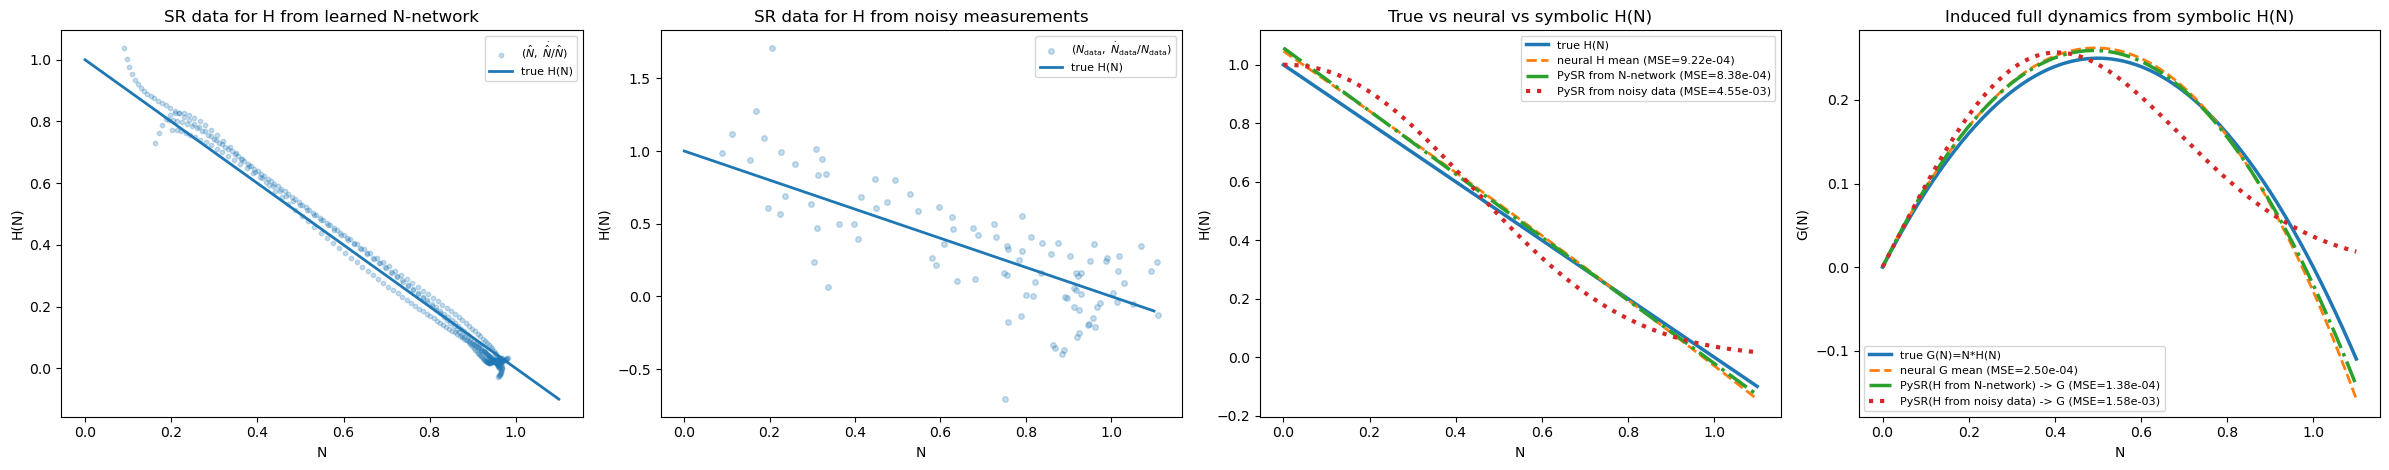


Selected equation for H(N) from solution-net derivatives:
complexity                                                  5
loss                                                 0.000121
equation                        (0.98034215 - x0) * 1.0789025
score                                                 0.78433
sympy_format                      (0.98034215 - x0)*1.0789025
lambda_format    PySRFunction(X=>(0.98034215 - x0)*1.0789025)
Name: 2, dtype: object

Selected equation for H(N) from noisy measurements:
complexity                                                   5
loss                                                  0.000171
equation                        0.036493603 ^ (x0 ^ 2.1946447)
score                                                 1.570797
sympy_format                      0.036493603**(x0**2.1946447)
lambda_format    PySRFunction(X=>0.036493603**(x0**2.1946447))
Name: 2, dtype: object
  - outputs/20260311_114603_vEiGhY/hall_of_fame.csv


In [38]:
# ============================================================
# 13. Symbolic regression (PySR) for H(N)
#     Model assumption:
#         dN/dt = N * H(N)
#
#     (A) use H_hat = (dN_hat/dt) / N_hat from learned solution nets
#     (B) use H_data = (dN_data/dt) / N_data from noisy measurements
#
#     We compare symbolic H(N) against true H(N), and also compare
#     the induced G(N)=N*H(N) against true G(N).
# ============================================================
from pysr import PySRRegressor

# ------------------------------------------------------------
# Helper: rebuild best solution nets
# ------------------------------------------------------------
def rebuild_best_solnets(best_state, n_ics, hidden_dim_sol, device):
    solnet_list = []
    for i in range(n_ics):
        net = SolutionNet(hidden_dim=hidden_dim_sol).to(device)
        net.load_state_dict(best_state["sol_nets"][i])
        net.eval()
        solnet_list.append(net)
    return solnet_list


# ------------------------------------------------------------
# Collect SR data for H from learned solution nets
#   X = N_hat
#   y = H_hat = (dN_hat/dt) / N_hat
# ------------------------------------------------------------
def collect_sr_data_for_H_from_solution_nets(solnet_list, t_eval, n_min=1e-4):
    X_all = []
    y_all = []

    for sol_net in solnet_list:
        t_req = t_eval.clone().detach().requires_grad_(True)
        N_hat = sol_net(t_req)

        dN_dt_hat = torch.autograd.grad(
            outputs=N_hat,
            inputs=t_req,
            grad_outputs=torch.ones_like(N_hat),
            create_graph=False,
            retain_graph=False,
        )[0]

        N_np = N_hat.detach().cpu().numpy().reshape(-1)
        dN_dt_np = dN_dt_hat.detach().cpu().numpy().reshape(-1)

        mask = np.isfinite(N_np) & np.isfinite(dN_dt_np) & (N_np > n_min)

        X_all.append(N_np[mask].reshape(-1, 1))
        y_all.append((dN_dt_np[mask] / N_np[mask]).reshape(-1))

    X_all = np.vstack(X_all)
    y_all = np.concatenate(y_all)

    mask = np.isfinite(X_all[:, 0]) & np.isfinite(y_all)
    return X_all[mask], y_all[mask]


# ------------------------------------------------------------
# Collect SR data for H directly from noisy measurements
#   X = N_data
#   y = H_data = (dN_data/dt) / N_data
# ------------------------------------------------------------
def collect_sr_data_for_H_from_noisy_measurements(y_data_all, t_obs, n_min=1e-4):
    t_np = t_obs.squeeze(1).cpu().numpy()
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()   # [n_ics, numpts]

    X_all = []
    y_all = []

    for i in range(y_data_np.shape[0]):
        y_i = y_data_np[i]
        dy_dt_i = np.gradient(y_i, t_np)

        mask = np.isfinite(y_i) & np.isfinite(dy_dt_i) & (y_i > n_min)

        X_all.append(y_i[mask].reshape(-1, 1))
        y_all.append((dy_dt_i[mask] / y_i[mask]).reshape(-1))

    X_all = np.vstack(X_all)
    y_all = np.concatenate(y_all)

    mask = np.isfinite(X_all[:, 0]) & np.isfinite(y_all)
    return X_all[mask], y_all[mask]

# ------------------------------------------------------------
# Choose best split and rebuild best solution nets
# ------------------------------------------------------------
best_split_idx = int(np.argmin(best_val_losses))
best_state_for_sr = best_states[best_split_idx]

solnets_best = rebuild_best_solnets(
    best_state=best_state_for_sr,
    n_ics=n_ics,
    hidden_dim_sol=hidden_dim_sol,
    device=device,
)

# Dense time grid for SR data from learned trajectories
t_sr_dense = torch.linspace(0.0, 6.0, 50, device=device).view(-1, 1)

X_h_pinn_sr, y_h_pinn_sr = collect_sr_data_for_H_from_solution_nets(
    solnets_best,
    t_sr_dense,
    n_min=1e-4,
)

X_h_noisy_sr, y_h_noisy_sr = collect_sr_data_for_H_from_noisy_measurements(
    y_data_all,
    t_obs,
    n_min=1e-4,
)

print("\nSR dataset sizes for H(N)")
print("-------------------------")
print(f"From solution-net derivatives: X shape = {X_h_pinn_sr.shape}, y shape = {y_h_pinn_sr.shape}")
print(f"From noisy measurements      : X shape = {X_h_noisy_sr.shape}, y shape = {y_h_noisy_sr.shape}")

# ------------------------------------------------------------
# Fit PySR models for H(N)
# ------------------------------------------------------------
pysr_h_pinn = fit_pysr_1d(
    X_h_pinn_sr,
    y_h_pinn_sr,
    niterations=20,
    populations=20,
    maxsize=7,
    random_state=123,
)

pysr_h_noisy = fit_pysr_1d(
    X_h_noisy_sr,
    y_h_noisy_sr,
    niterations=20,
    populations=20,
    maxsize=7,
    random_state=456,
)

print("\nBest symbolic model for H(N) from solution-net derivatives")
print("-----------------------------------------------------------")
print(pysr_h_pinn)

print("\nBest symbolic model for H(N) from noisy measurements")
print("----------------------------------------------------")
print(pysr_h_noisy)

# ------------------------------------------------------------
# Evaluate on N_grid
# ------------------------------------------------------------
N_grid_np = N_grid.detach().cpu().numpy().reshape(-1, 1)
N_grid_flat = N_grid_np[:, 0]

H_true_np = H_true(N_grid).detach().cpu().numpy().reshape(-1)
G_true_np = G_true(N_grid).detach().cpu().numpy().reshape(-1)

# Neural network mean estimate of H from training
H_nn_np = h_mean
G_nn_np = rhs_mean

# Symbolic H predictions
H_sr_pinn_np = safe_predict(pysr_h_pinn, N_grid_np)
H_sr_noisy_np = safe_predict(pysr_h_noisy, N_grid_np)

# Induced G = N * H
G_sr_pinn_np = N_grid_flat * H_sr_pinn_np
G_sr_noisy_np = N_grid_flat * H_sr_noisy_np

# ------------------------------------------------------------
# MSEs
# ------------------------------------------------------------
mse_h_nn = np.mean((H_nn_np - H_true_np) ** 2)
mse_h_sr_pinn = np.mean((H_sr_pinn_np - H_true_np) ** 2)
mse_h_sr_noisy = np.mean((H_sr_noisy_np - H_true_np) ** 2)

mse_g_nn = np.mean((G_nn_np - G_true_np) ** 2)
mse_g_sr_pinn = np.mean((G_sr_pinn_np - G_true_np) ** 2)
mse_g_sr_noisy = np.mean((G_sr_noisy_np - G_true_np) ** 2)

print("\nMSE on N_grid against true H(N)")
print("-------------------------------")
print(f"Neural dyn_net mean H MSE          : {mse_h_nn:.6e}")
print(f"PySR from solution-net H MSE       : {mse_h_sr_pinn:.6e}")
print(f"PySR from noisy-measurement H MSE  : {mse_h_sr_noisy:.6e}")

print("\nMSE on N_grid against true G(N)=N*H(N)")
print("--------------------------------------")
print(f"Neural dyn_net mean G MSE          : {mse_g_nn:.6e}")
print(f"PySR from solution-net H -> G MSE  : {mse_g_sr_pinn:.6e}")
print(f"PySR from noisy H -> G MSE         : {mse_g_sr_noisy:.6e}")

# ------------------------------------------------------------
# Plots
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(24, 4.8))

# SR dataset from learned solution nets
axes[0].scatter(
    X_h_pinn_sr[:, 0],
    y_h_pinn_sr,
    s=10,
    alpha=0.25,
    label=r"$(\hat N,\; \dot{\hat N}/\hat N)$",
)
axes[0].plot(
    N_grid_flat,
    H_true_np,
    linewidth=2,
    label="true H(N)",
)
axes[0].set_xlabel("N")
axes[0].set_ylabel("H(N)")
axes[0].set_title("SR data for H from learned N-network")
axes[0].legend(fontsize=8)

# SR dataset from noisy measurements
axes[1].scatter(
    X_h_noisy_sr[:, 0],
    y_h_noisy_sr,
    s=16,
    alpha=0.25,
    label=r"$(N_{\mathrm{data}},\; \dot N_{\mathrm{data}}/N_{\mathrm{data}})$",
)
axes[1].plot(
    N_grid_flat,
    H_true_np,
    linewidth=2,
    label="true H(N)",
)
axes[1].set_xlabel("N")
axes[1].set_ylabel("H(N)")
axes[1].set_title("SR data for H from noisy measurements")
axes[1].legend(fontsize=8)

# H comparison
axes[2].plot(
    N_grid_flat,
    H_true_np,
    linewidth=2.5,
    label="true H(N)",
)
axes[2].plot(
    N_grid_flat,
    H_nn_np,
    "--",
    linewidth=2,
    label=f"neural H mean (MSE={mse_h_nn:.2e})",
)
axes[2].plot(
    N_grid_flat,
    H_sr_pinn_np,
    "-.",
    linewidth=2.5,
    label=f"PySR from N-network (MSE={mse_h_sr_pinn:.2e})",
)
axes[2].plot(
    N_grid_flat,
    H_sr_noisy_np,
    ":",
    linewidth=3.0,
    label=f"PySR from noisy data (MSE={mse_h_sr_noisy:.2e})",
)
axes[2].set_xlabel("N")
axes[2].set_ylabel("H(N)")
axes[2].set_title("True vs neural vs symbolic H(N)")
axes[2].legend(fontsize=8)

# Induced G comparison
axes[3].plot(
    N_grid_flat,
    G_true_np,
    linewidth=2.5,
    label="true G(N)=N*H(N)",
)
axes[3].plot(
    N_grid_flat,
    G_nn_np,
    "--",
    linewidth=2,
    label=f"neural G mean (MSE={mse_g_nn:.2e})",
)
axes[3].plot(
    N_grid_flat,
    G_sr_pinn_np,
    "-.",
    linewidth=2.5,
    label=f"PySR(H from N-network) -> G (MSE={mse_g_sr_pinn:.2e})",
)
axes[3].plot(
    N_grid_flat,
    G_sr_noisy_np,
    ":",
    linewidth=3.0,
    label=f"PySR(H from noisy data) -> G (MSE={mse_g_sr_noisy:.2e})",
)
axes[3].set_xlabel("N")
axes[3].set_ylabel("G(N)")
axes[3].set_title("Induced full dynamics from symbolic H(N)")
axes[3].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Print equations
# ------------------------------------------------------------
try:
    print("\nSelected equation for H(N) from solution-net derivatives:")
    print(pysr_h_pinn.get_best())

    print("\nSelected equation for H(N) from noisy measurements:")
    print(pysr_h_noisy.get_best())
except Exception as e:
    print("\nCould not print get_best() details.")
    print(f"Reason: {e}")


Starting PINN split 1/1
Dynamics init seed for split 1: 10000
Structure init seed for split 1: 30000
Solution init seeds for split 1: [20000, 20001, 20002, 20003]
Using structure: dN/dt = N * (a - bN) * H(N)
Initial a = 1.000000
PINN | Split  1/1 | Epoch     1/3000 | Train Total: 7.041915e-01 | Train Data: 7.015274e-01 | Train Phys: 2.664070e-03 | Train Anchor: 2.909430e-02 | a: 1.001000 | Val Total: 5.830939e-01 | Val Data: 5.807470e-01 | Val Phys: 2.346937e-03
PINN | Split  1/1 | Epoch   500/3000 | Train Total: 4.740868e-03 | Train Data: 4.360047e-03 | Train Phys: 3.808211e-04 | Train Anchor: 1.392026e-05 | a: 0.991362 | Val Total: 3.976290e-03 | Val Data: 3.630301e-03 | Val Phys: 3.459885e-04
PINN | Split  1/1 | Epoch  1000/3000 | Train Total: 4.493382e-03 | Train Data: 4.189652e-03 | Train Phys: 3.037306e-04 | Train Anchor: 4.316505e-05 | a: 0.985676 | Val Total: 3.478347e-03 | Val Data: 3.233072e-03 | Val Phys: 2.452745e-04
PINN | Split  1/1 | Epoch  1500/3000 | Train Total: 4.30

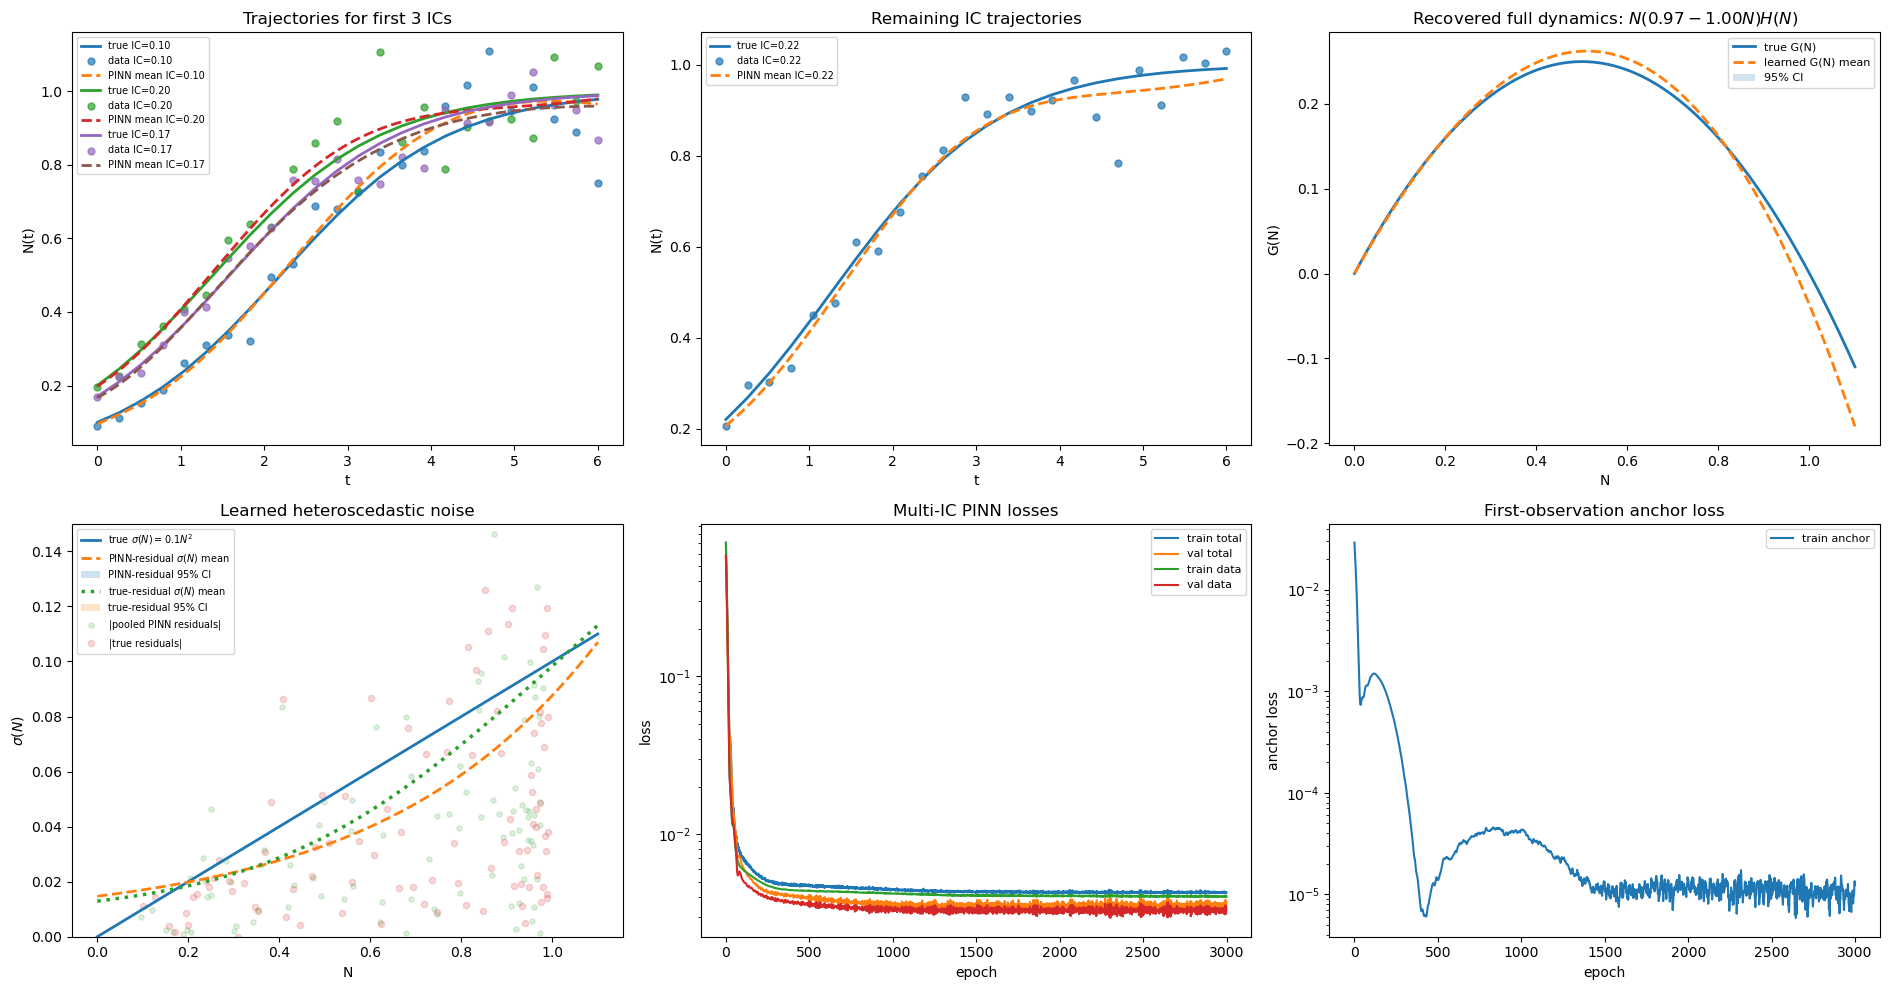

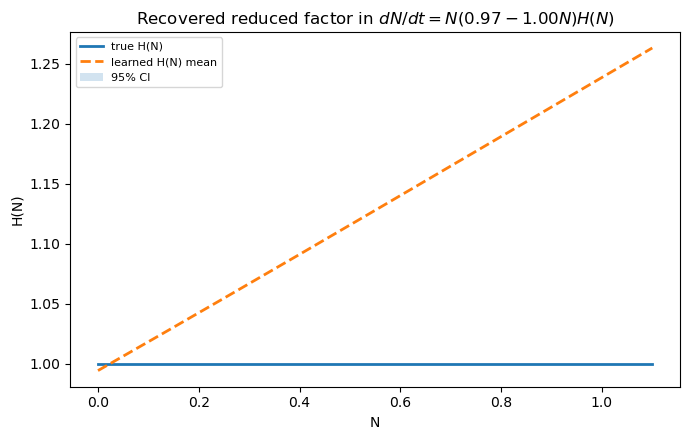

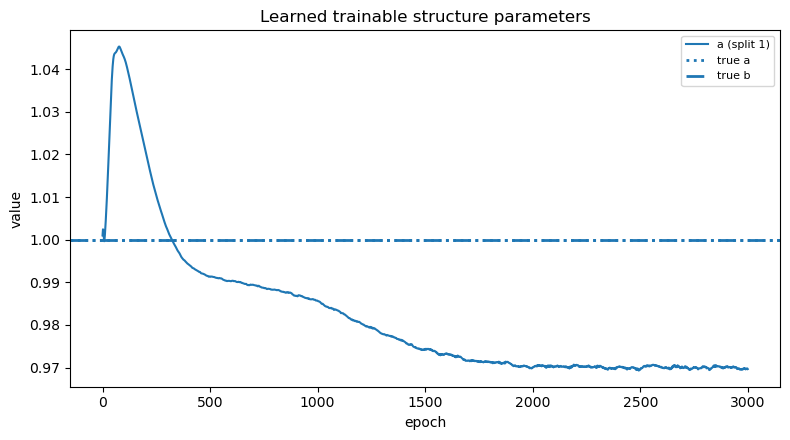

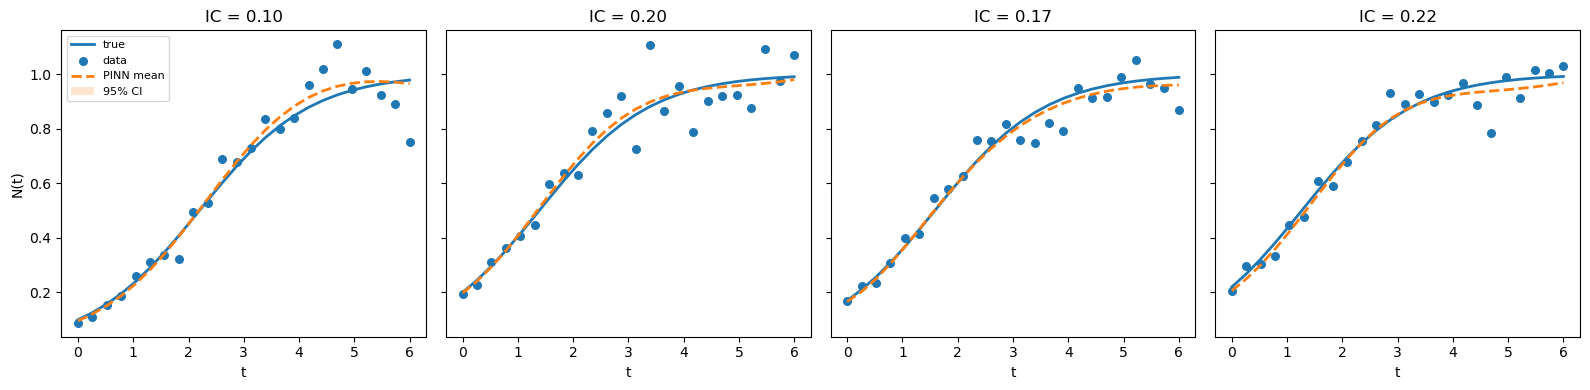

/var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/ipykernel_9670/2312806150.py:857: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[0].set_yscale("log")


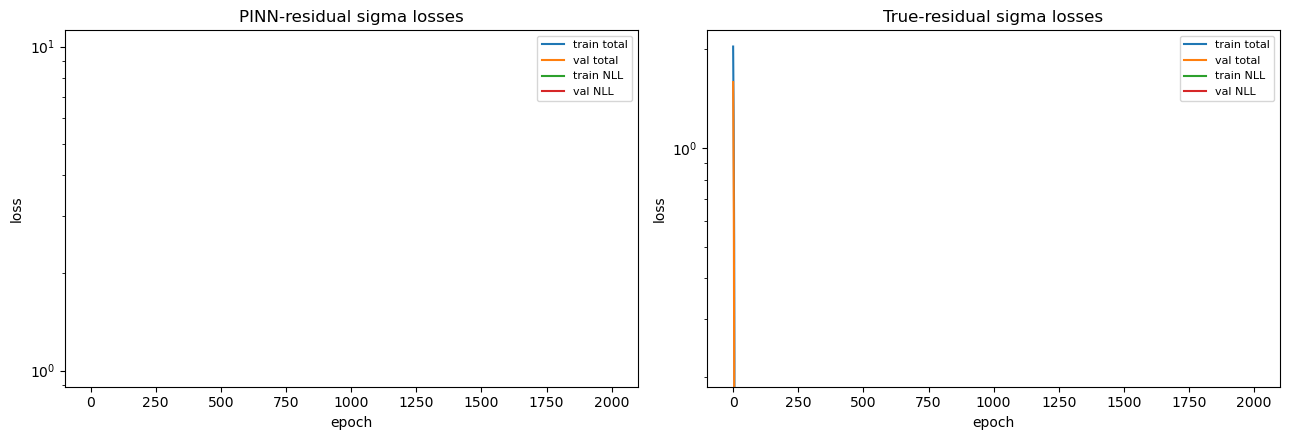


Multi-IC PINN summary
---------------------
Number of trajectories / ICs: 4
Synthetic IC values used to generate data: [0.1, 0.2, 0.17, 0.22]
Number of PINN splits: 1
Validation fraction: 0.2
Model-selection criterion: validation loss
Mean best selection loss: 3.183782e-03
Std  best selection loss: N/A (only one split)
Mean best epoch: 2304.00
Std  best epoch: N/A (only one split)
Anchor weight lambda_anchor: 0.000
True structure:  dN/dt = N(1.0000 - 1.0000N)H_true(N)
Learned mean a: 0.970167
Learned mean b: 1.000000
Model structure: dN/dt = N(a - bN)H(N), with dyn_net learning H(N)

Initialization summary by split
-------------------------------
Split 1: dyn_init_seed=10000, ab_init_seed=30000, sol_init_seeds=[20000, 20001, 20002, 20003], selection_criterion=val

PINN-residual sigma summary
---------------------------
Number of sigma repeats: 1
Mean best selection loss: -4.898736e+00
Std  best selection loss: N/A (only one repeat)
Mean best epoch: 1999.00
Std  best epoch: N/A (only o

In [45]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")

# ============================================================
# True structure and model-side trainable structure
# ============================================================
a_true = 1.0
b_true = 1.0

def H_true(N):
    # Example: constant reduced factor
    return r_true * torch.ones_like(N)

def G_true(N):
    return N * (a_true - b_true * N) * H_true(N)

with torch.no_grad():
    G_grid_true = G_true(N_grid)
    H_grid_true = H_true(N_grid)
    sigma_true_grid = 0.1 * N_grid

# ============================================================
# Trainable scalar parameters for N(a - bN)
# ============================================================
class TrainableStructure(nn.Module):
    def __init__(self, a_init=1.0, b_init=1.0):
        super().__init__()
        self.a = nn.Parameter(torch.tensor(float(a_init), dtype=torch.float32))
        self.b = 1#nn.Parameter(torch.tensor(float(b_init), dtype=torch.float32))

    def forward(self):
        return self.a, self.b


# ============================================================
# 4. Helper functions
# ============================================================
def pinn_physics_residual(sol_net, dyn_net, struct_params, t_col):
    """
    Physics model:
        dN/dt = N (a - bN) H(N)
    where:
        dyn_net(N) approximates H(N),
        a and b are trainable scalar parameters.
    """
    N_pred_col = sol_net(t_col)
    dN_dt = torch.autograd.grad(
        outputs=N_pred_col,
        inputs=t_col,
        grad_outputs=torch.ones_like(N_pred_col),
        create_graph=True,
        retain_graph=True,
    )[0]

    a_param, b_param = struct_params()
    h_pred = dyn_net(N_pred_col)
    rhs_pred = N_pred_col * (a_param - b_param * N_pred_col) * h_pred
    phys_res = dN_dt - rhs_pred
    return N_pred_col, dN_dt, h_pred, rhs_pred, phys_res, a_param, b_param


# ============================================================
# 5. Multi-IC PINN fit
# ============================================================
n_col = 1000
t_col_base = torch.linspace(0.0, 6.0, n_col, device=device).view(-1, 1)

n_epochs = 3000
n_splits = 1
print_every = 500
batch_obs = 24 * 4 * n_ics
batch_col = 100

val_fraction = 0.2
n_obs = t_obs.shape[0]
use_validation = val_fraction > 0.0 and n_obs > 1

if use_validation:
    n_val = int(round(val_fraction * n_obs))
    n_val = max(1, min(n_val, n_obs - 1))
else:
    n_val = 0
n_train = n_obs - n_val

lambda_phys = 1.0
lambda_anchor = 0.0
learning_rate = 1e-3
hidden_dim_sol = 32
hidden_dim_dyn = 32

# optional mild regularization toward positive / interpretable values
lambda_ab_reg = 0.0

data_split_seed_base = 1000
dyn_init_seed_base = 10000
sol_init_seed_base = 20000
ab_init_seed_base = 30000

train_total_histories = []
train_data_histories = []
train_phys_histories = []
train_anchor_histories = []
train_ab_histories = []

val_total_histories = []
val_data_histories = []
val_phys_histories = []

traj_histories = []
rhs_histories = []   # learned full G(N) = N(a-bN)H(N)
h_histories = []     # learned reduced factor H(N)
a_histories = []
b_histories = []
obs_fit_histories = []

best_val_losses = []
best_epochs = []
best_states = []

for split in range(n_splits):
    print(f"\n{'=' * 90}")
    print(f"Starting PINN split {split + 1}/{n_splits}")
    print(f"{'=' * 90}")

    g = torch.Generator(device=device)
    g.manual_seed(data_split_seed_base + split)

    perm = torch.randperm(n_obs, generator=g, device=device)
    train_idx = perm[:n_train].sort().values

    if use_validation:
        val_idx = perm[n_train:].sort().values
    else:
        val_idx = torch.empty(0, dtype=torch.long, device=device)

    torch.manual_seed(dyn_init_seed_base + split)
    np.random.seed(dyn_init_seed_base + split)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)

    torch.manual_seed(ab_init_seed_base + split)
    np.random.seed(ab_init_seed_base + split)
    struct_params = TrainableStructure(a_init=1.0).to(device)

    sol_net_list = []
    sol_init_seeds_this_split = []
    for i in range(n_ics):
        init_seed = sol_init_seed_base + 1000 * split + i
        sol_init_seeds_this_split.append(init_seed)
        torch.manual_seed(init_seed)
        np.random.seed(init_seed)
        sol_net_list.append(SolutionNet(hidden_dim=hidden_dim_sol).to(device))

    sol_nets = nn.ModuleList(sol_net_list)

    print(f"Dynamics init seed for split {split + 1}: {dyn_init_seed_base + split}")
    print(f"Structure init seed for split {split + 1}: {ab_init_seed_base + split}")
    print(f"Solution init seeds for split {split + 1}: {sol_init_seeds_this_split}")
    print("Using structure: dN/dt = N * (a - bN) * H(N)")
    print(f"Initial a = {struct_params.a.item():.6f}")

    optimizer = torch.optim.Adam(
        list(dyn_net.parameters()) +
        list(sol_nets.parameters()) +
        list(struct_params.parameters()),
        lr=learning_rate,
    )

    train_total_history = []
    train_data_history = []
    train_phys_history = []
    train_anchor_history = []
    train_ab_history = []

    val_total_history = []
    val_data_history = []
    val_phys_history = []

    best_criterion = float("inf")
    best_epoch = -1
    best_state = None

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        total_data_loss = 0.0
        total_phys_loss = 0.0
        total_anchor_loss = 0.0

        for i in range(n_ics):
            sol_net = sol_nets[i]

            obs_sel = train_idx[torch.randperm(len(train_idx), device=device)[:batch_obs]]
            t_train = t_obs[obs_sel]
            y_train = y_data_all[i][obs_sel]

            N_pred_train = sol_net(t_train)
            data_loss = torch.mean((N_pred_train - y_train) ** 2)

            t_col = 6.0 * torch.rand(batch_col, 1, device=device)
            t_col.requires_grad_(True)
            _, _, _, _, phys_res, _, _ = pinn_physics_residual(
                sol_net, dyn_net, struct_params, t_col
            )
            phys_loss = torch.mean(phys_res ** 2)

            t0_obs = t_obs[0:1]
            y0_obs = y_data_all[i][0:1]
            N0_pred = sol_net(t0_obs)
            anchor_loss = torch.mean((N0_pred - y0_obs) ** 2)

            total_data_loss += data_loss
            total_phys_loss += phys_loss
            total_anchor_loss += anchor_loss

        total_data_loss /= n_ics
        total_phys_loss /= n_ics
        total_anchor_loss /= n_ics

        # Optional regularization / soft constraints on a,b
        a_now, b_now = struct_params()
        ab_reg = lambda_ab_reg * (
            torch.relu(-a_now) ** 2 
        )

        train_loss = (
            total_data_loss
            + lambda_phys * total_phys_loss
            + lambda_anchor * total_anchor_loss
            + ab_reg
        )
        train_loss.backward()
        optimizer.step()

        if use_validation:
            with torch.no_grad():
                total_val_data_loss = 0.0
                for i in range(n_ics):
                    sol_net = sol_nets[i]
                    t_val = t_obs[val_idx]
                    y_val = y_data_all[i][val_idx]
                    N_pred_val = sol_net(t_val)
                    total_val_data_loss = total_val_data_loss + torch.mean((N_pred_val - y_val) ** 2)
                total_val_data_loss = total_val_data_loss / n_ics

            total_val_phys_loss = 0.0
            for i in range(n_ics):
                sol_net = sol_nets[i]
                t_col_val = t_col_base.clone().detach().requires_grad_(True)
                _, _, _, _, val_phys_res, _, _ = pinn_physics_residual(
                    sol_net, dyn_net, struct_params, t_col_val
                )
                total_val_phys_loss = total_val_phys_loss + torch.mean(val_phys_res ** 2)

            total_val_phys_loss = total_val_phys_loss / n_ics
            val_loss = total_val_data_loss + lambda_phys * total_val_phys_loss

            criterion_value = val_loss.item()
            criterion_name = "val"

            val_total_item = val_loss.item()
            val_data_item = total_val_data_loss.item()
            val_phys_item = total_val_phys_loss.item()
        else:
            criterion_value = train_loss.item()
            criterion_name = "train"

            val_total_item = np.nan
            val_data_item = np.nan
            val_phys_item = np.nan

        train_total_history.append(train_loss.item())
        train_data_history.append(total_data_loss.item())
        train_phys_history.append(total_phys_loss.item())
        train_anchor_history.append(total_anchor_loss.item())
        train_ab_history.append([a_now.item()])

        val_total_history.append(val_total_item)
        val_data_history.append(val_data_item)
        val_phys_history.append(val_phys_item)

        if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
            if use_validation:
                print(
                    f"PINN | Split {split + 1:2d}/{n_splits} | "
                    f"Epoch {epoch + 1:5d}/{n_epochs} | "
                    f"Train Total: {train_loss.item():.6e} | "
                    f"Train Data: {total_data_loss.item():.6e} | "
                    f"Train Phys: {total_phys_loss.item():.6e} | "
                    f"Train Anchor: {total_anchor_loss.item():.6e} | "
                    f"a: {a_now.item():.6f} | "
                    f"Val Total: {val_total_item:.6e} | "
                    f"Val Data: {val_data_item:.6e} | "
                    f"Val Phys: {val_phys_item:.6e}"
                )
            else:
                print(
                    f"PINN | Split {split + 1:2d}/{n_splits} | "
                    f"Epoch {epoch + 1:5d}/{n_epochs} | "
                    f"Train Total: {train_loss.item():.6e} | "
                    f"Train Data: {total_data_loss.item():.6e} | "
                    f"Train Phys: {total_phys_loss.item():.6e} | "
                    f"Train Anchor: {total_anchor_loss.item():.6e} | "
                    f"a: {a_now.item():.6f} | b: {b_now.item():.6f} | "
                    f"Val Total: N/A | Val Data: N/A | Val Phys: N/A | "
                    f"Best-model criterion: training loss"
                )

        if criterion_value < best_criterion:
            best_criterion = criterion_value
            best_epoch = epoch
            best_state = {
                "dyn_net": copy.deepcopy(dyn_net.state_dict()),
                "sol_nets": [copy.deepcopy(sol_net.state_dict()) for sol_net in sol_nets],
                "struct_params": copy.deepcopy(struct_params.state_dict()),
                "dyn_init_seed": dyn_init_seed_base + split,
                "ab_init_seed": ab_init_seed_base + split,
                "sol_init_seeds": sol_init_seeds_this_split.copy(),
                "train_idx": train_idx.clone(),
                "val_idx": val_idx.clone(),
                "selection_criterion": criterion_name,
            }

    if use_validation:
        print(
            f"Finished PINN split {split + 1:2d}/{n_splits} | "
            f"Best epoch = {best_epoch:5d} | Best val loss = {best_criterion:.6e}"
        )
    else:
        print(
            f"Finished PINN split {split + 1:2d}/{n_splits} | "
            f"Best epoch = {best_epoch:5d} | Best train loss = {best_criterion:.6e}"
        )

    dyn_net.load_state_dict(best_state["dyn_net"])
    struct_params.load_state_dict(best_state["struct_params"])
    for i in range(n_ics):
        sol_nets[i].load_state_dict(best_state["sol_nets"][i])

    dyn_net.eval()
    struct_params.eval()
    for sol_net in sol_nets:
        sol_net.eval()

    with torch.no_grad():
        trajs_this_split = []
        obs_fits_this_split = []

        for i in range(n_ics):
            trajs_this_split.append(sol_nets[i](t_plot).squeeze(1).cpu().numpy())
            obs_fits_this_split.append(sol_nets[i](t_obs).squeeze(1).cpu().numpy())

        H_grid_learned = dyn_net(N_grid).squeeze(1).cpu().numpy()
        N_np = N_grid.squeeze(1).cpu().numpy()

        a_best = struct_params.a.item()

        G_grid_learned = N_np * (a_best - 1 * N_np) * H_grid_learned

    train_total_histories.append(train_total_history)
    train_data_histories.append(train_data_history)
    train_phys_histories.append(train_phys_history)
    train_anchor_histories.append(train_anchor_history)
    train_ab_histories.append(np.array(train_ab_history))

    val_total_histories.append(val_total_history)
    val_data_histories.append(val_data_history)
    val_phys_histories.append(val_phys_history)

    traj_histories.append(np.array(trajs_this_split))
    obs_fit_histories.append(np.array(obs_fits_this_split))
    rhs_histories.append(G_grid_learned)
    h_histories.append(H_grid_learned)
    a_histories.append(a_best)
    b_histories.append(1)

    best_val_losses.append(best_criterion)
    best_epochs.append(best_epoch)
    best_states.append(best_state)

train_total_histories = np.array(train_total_histories)
train_data_histories = np.array(train_data_histories)
train_phys_histories = np.array(train_phys_histories)
train_anchor_histories = np.array(train_anchor_histories)
train_ab_histories = np.array(train_ab_histories)

val_total_histories = np.array(val_total_histories)
val_data_histories = np.array(val_data_histories)
val_phys_histories = np.array(val_phys_histories)

traj_histories = np.array(traj_histories)
obs_fit_histories = np.array(obs_fit_histories)
rhs_histories = np.array(rhs_histories)
h_histories = np.array(h_histories)
a_histories = np.array(a_histories)
b_histories = np.array(b_histories)

rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)
h_mean, h_lo, h_hi = mean_and_ci(h_histories)

traj_mean_per_ic = []
traj_lo_per_ic = []
traj_hi_per_ic = []

obs_fit_mean_per_ic = []
obs_fit_lo_per_ic = []
obs_fit_hi_per_ic = []

for i in range(n_ics):
    m, lo, hi = mean_and_ci(traj_histories[:, i, :])
    traj_mean_per_ic.append(m)
    traj_lo_per_ic.append(lo)
    traj_hi_per_ic.append(hi)

    m, lo, hi = mean_and_ci(obs_fit_histories[:, i, :])
    obs_fit_mean_per_ic.append(m)
    obs_fit_lo_per_ic.append(lo)
    obs_fit_hi_per_ic.append(hi)

a_mean = np.mean(a_histories)
b_mean = np.mean(b_histories)

# ============================================================
# 6. Learn sigma(N) from pooled multi-IC PINN residuals
# ============================================================
with torch.no_grad():
    y_rep = y_data_all.squeeze(-1).cpu().numpy()[None, :, :]
    resid_pinn_all_np = y_rep - obs_fit_histories

    N_pinn_sigma_all_np = obs_fit_histories.reshape(-1, 1)
    resid_pinn_sigma_all_np = resid_pinn_all_np.reshape(-1, 1)

    mask = N_pinn_sigma_all_np.squeeze() > 0.0
    N_pinn_sigma_all_np = N_pinn_sigma_all_np[mask]
    resid_pinn_sigma_all_np = resid_pinn_all_np.reshape(-1, 1)[mask]

N_pinn_sigma_all = torch.tensor(N_pinn_sigma_all_np, dtype=torch.float32, device=device)
resid_pinn_sigma_all = torch.tensor(resid_pinn_sigma_all_np, dtype=torch.float32, device=device)

N_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_pinn_sigma_all.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_pinn_results = fit_sigma_repeated(
    N_all=N_pinn_sigma_all,
    resid_all=resid_pinn_sigma_all,
    N_eval_grid=N_grid,
    N_col_base=N_sigma_col_base,
    n_repeats=1,
    val_fraction=0.4,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="PINN-sigma",
    print_every=250,
)

sigma_pinn_mean, sigma_pinn_lo, sigma_pinn_hi = mean_and_ci(
    sigma_pinn_results["curve_histories"]
)

# ============================================================
# 7. Learn sigma_truefit(N) from true residuals
# ============================================================
with torch.no_grad():
    N_true_sigma_np = y_true_all.squeeze(-1).cpu().numpy().reshape(-1, 1)
    resid_true_sigma_np = (y_data_all - y_true_all).squeeze(-1).cpu().numpy().reshape(-1, 1)

    mask_true = N_true_sigma_np.squeeze() > 0.0
    N_true_sigma_np = N_true_sigma_np[mask_true]
    resid_true_sigma_np = resid_true_sigma_np[mask_true]

N_true_sigma = torch.tensor(N_true_sigma_np, dtype=torch.float32, device=device)
resid_true_sigma = torch.tensor(resid_true_sigma_np, dtype=torch.float32, device=device)

N_true_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_true_sigma.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_truefit_results = fit_sigma_repeated(
    N_all=N_true_sigma,
    resid_all=resid_true_sigma,
    N_eval_grid=N_grid,
    N_col_base=N_true_sigma_col_base,
    n_repeats=1,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=9000,
    seed_offset_model=11000,
    label="TRUE-sigma",
    print_every=250,
)

sigma_truefit_mean, sigma_truefit_lo, sigma_truefit_hi = mean_and_ci(
    sigma_truefit_results["curve_histories"]
)

# ============================================================
# 8. Residuals across all ICs using mean PINN fit
# ============================================================
with torch.no_grad():
    obs_fit_mean_all = np.array(obs_fit_mean_per_ic)
    y_true_np = y_true_all.squeeze(-1).cpu().numpy()
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()

    residuals_all = y_data_np - obs_fit_mean_all
    N_fit_all = obs_fit_mean_all.reshape(-1, 1)
    residuals_flat = residuals_all.reshape(-1, 1)

    mask = N_fit_all.squeeze() > 0.0
    N_fit_all = N_fit_all[mask]
    residuals_flat = residuals_flat[mask]

# ============================================================
# 9. Plots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

# ------------------------------------------------------------
# Trajectories
# ------------------------------------------------------------
for i in range(min(3, n_ics)):
    axes[0, 0].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 0].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 0].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"PINN mean IC={N0_list[i]:.2f}",
    )
    axes[0, 0].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("N(t)")
axes[0, 0].set_title("Trajectories for first 3 ICs")
axes[0, 0].legend(fontsize=7)

# ------------------------------------------------------------
# Remaining ICs
# ------------------------------------------------------------
for i in range(3, n_ics):
    axes[0, 1].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 1].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 1].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"PINN mean IC={N0_list[i]:.2f}",
    )
    axes[0, 1].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 1].set_xlabel("t")
axes[0, 1].set_ylabel("N(t)")
axes[0, 1].set_title("Remaining IC trajectories")
axes[0, 1].legend(fontsize=7)

# ------------------------------------------------------------
# Recovered full dynamics G(N) = N(a-bN)H(N)
# ------------------------------------------------------------
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    G_grid_true.squeeze(1).cpu().numpy(),
    label="true G(N)",
    linewidth=2,
)
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="learned G(N) mean",
)
axes[0, 2].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.20,
    label="95% CI",
)
axes[0, 2].set_xlabel("N")
axes[0, 2].set_ylabel("G(N)")
axes[0, 2].set_title(rf"Recovered full dynamics: $N({a_mean:.2f}-{b_mean:.2f}N)H(N)$")
axes[0, 2].legend(fontsize=8)

# ------------------------------------------------------------
# Learned sigma(N)
# ------------------------------------------------------------
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_true_grid.squeeze(1).cpu().numpy(),
    linewidth=2,
    label=r"true $\sigma(N)=0.1N^2$",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=r"PINN-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_truefit_mean,
    ":",
    linewidth=2.5,
    label=r"true-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI",
)
axes[1, 0].scatter(
    N_pinn_sigma_all.cpu().numpy().squeeze(),
    np.abs(resid_pinn_sigma_all.cpu().numpy().squeeze()),
    s=14,
    alpha=0.16,
    label=r"$|$pooled PINN residuals$|$",
)
axes[1, 0].scatter(
    N_true_sigma.cpu().numpy().squeeze(),
    np.abs(resid_true_sigma.cpu().numpy().squeeze()),
    s=20,
    alpha=0.18,
    label=r"$|$true residuals$|$",
)
axes[1, 0].set_xlabel("N")
axes[1, 0].set_ylabel(r"$\sigma(N)$")
axes[1, 0].set_title("Learned heteroscedastic noise")
axes[1, 0].legend(fontsize=7)
axes[1, 0].set_ylim(0, 0.15)

# ------------------------------------------------------------
# PINN losses
# ------------------------------------------------------------
epochs_init = np.arange(n_epochs)

train_total_mean, train_total_lo, train_total_hi = mean_and_ci(train_total_histories)
val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)
val_data_mean, val_data_lo, val_data_hi = mean_and_ci(val_data_histories)

axes[1, 1].plot(epochs_init, train_total_mean, label="train total")
axes[1, 1].fill_between(epochs_init, train_total_lo, train_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_total_mean, label="val total")
axes[1, 1].fill_between(epochs_init, val_total_lo, val_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, train_data_mean, label="train data")
axes[1, 1].fill_between(epochs_init, train_data_lo, train_data_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_data_mean, label="val data")
axes[1, 1].fill_between(epochs_init, val_data_lo, val_data_hi, alpha=0.2)
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylabel("loss")
axes[1, 1].set_title("Multi-IC PINN losses")
axes[1, 1].legend(fontsize=8)

# ------------------------------------------------------------
# Anchor loss
# ------------------------------------------------------------
train_anchor_mean, train_anchor_lo, train_anchor_hi = mean_and_ci(train_anchor_histories)
axes[1, 2].plot(epochs_init, train_anchor_mean, label="train anchor")
axes[1, 2].fill_between(epochs_init, train_anchor_lo, train_anchor_hi, alpha=0.2)
axes[1, 2].set_yscale("log")
axes[1, 2].set_xlabel("epoch")
axes[1, 2].set_ylabel("anchor loss")
axes[1, 2].set_title("First-observation anchor loss")
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Extra plot: recovered reduced factor H(N)
# ------------------------------------------------------------
plt.figure(figsize=(7, 4.5))
plt.plot(
    N_grid.cpu().numpy(),
    H_grid_true.squeeze(1).cpu().numpy(),
    label="true H(N)",
    linewidth=2,
)
plt.plot(
    N_grid.cpu().numpy(),
    h_mean,
    "--",
    linewidth=2,
    label="learned H(N) mean",
)
plt.fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    h_lo,
    h_hi,
    alpha=0.20,
    label="95% CI",
)
plt.xlabel("N")
plt.ylabel("H(N)")
plt.title(rf"Recovered reduced factor in $dN/dt = N({a_mean:.2f}-{b_mean:.2f}N)H(N)$")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Extra plot: trainable a and b across epochs
# ------------------------------------------------------------
if train_ab_histories.ndim == 3:
    plt.figure(figsize=(8, 4.5))
    for split in range(train_ab_histories.shape[0]):
        plt.plot(train_ab_histories[split, :, 0], label=f"a (split {split+1})")
        #plt.plot(train_ab_histories[split, :, 1], "--", label=f"b (split {split+1})")
    plt.axhline(a_true, linestyle=":", linewidth=2, label="true a")
    plt.axhline(1, linestyle="-.", linewidth=2, label="true b")
    plt.xlabel("epoch")
    plt.ylabel("value")
    plt.title("Learned trainable structure parameters")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

# ============================================================
# 10. Observation-time comparison
# ============================================================
fig, axs = plt.subplots(1, n_ics, figsize=(4 * n_ics, 4), sharey=True)

if n_ics == 1:
    axs = [axs]

for i in range(n_ics):
    axs[i].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        label="true",
        linewidth=2,
    )
    axs[i].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        label="data",
        s=30,
    )
    axs[i].plot(
        t_obs.cpu().numpy(),
        obs_fit_mean_per_ic[i],
        "--",
        linewidth=2,
        label="PINN mean",
    )
    axs[i].fill_between(
        t_obs.squeeze(1).cpu().numpy(),
        obs_fit_lo_per_ic[i],
        obs_fit_hi_per_ic[i],
        alpha=0.20,
        label="95% CI",
    )
    axs[i].set_title(f"IC = {N0_list[i]:.2f}")
    axs[i].set_xlabel("t")

axs[0].set_ylabel("N(t)")
axs[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

# ============================================================
# 11. Sigma training diagnostics
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

epochs_sigma = np.arange(sigma_pinn_results["train_total_histories"].shape[1])

sp_train_total_mean, sp_train_total_lo, sp_train_total_hi = mean_and_ci(
    sigma_pinn_results["train_total_histories"]
)
sp_val_total_mean, sp_val_total_lo, sp_val_total_hi = mean_and_ci(
    sigma_pinn_results["val_total_histories"]
)
sp_train_nll_mean, sp_train_nll_lo, sp_train_nll_hi = mean_and_ci(
    sigma_pinn_results["train_nll_histories"]
)
sp_val_nll_mean, sp_val_nll_lo, sp_val_nll_hi = mean_and_ci(
    sigma_pinn_results["val_nll_histories"]
)

axes[0].plot(epochs_sigma, sp_train_total_mean, label="train total")
axes[0].fill_between(epochs_sigma, sp_train_total_lo, sp_train_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_total_mean, label="val total")
axes[0].fill_between(epochs_sigma, sp_val_total_lo, sp_val_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_train_nll_mean, label="train NLL")
axes[0].fill_between(epochs_sigma, sp_train_nll_lo, sp_train_nll_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_nll_mean, label="val NLL")
axes[0].fill_between(epochs_sigma, sp_val_nll_lo, sp_val_nll_hi, alpha=0.2)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("PINN-residual sigma losses")
axes[0].legend(fontsize=8)

st_train_total_mean, st_train_total_lo, st_train_total_hi = mean_and_ci(
    sigma_truefit_results["train_total_histories"]
)
st_val_total_mean, st_val_total_lo, st_val_total_hi = mean_and_ci(
    sigma_truefit_results["val_total_histories"]
)
st_train_nll_mean, st_train_nll_lo, st_train_nll_hi = mean_and_ci(
    sigma_truefit_results["train_nll_histories"]
)
st_val_nll_mean, st_val_nll_lo, st_val_nll_hi = mean_and_ci(
    sigma_truefit_results["val_nll_histories"]
)

axes[1].plot(epochs_sigma, st_train_total_mean, label="train total")
axes[1].fill_between(epochs_sigma, st_train_total_lo, st_train_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_total_mean, label="val total")
axes[1].fill_between(epochs_sigma, st_val_total_lo, st_val_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_train_nll_mean, label="train NLL")
axes[1].fill_between(epochs_sigma, st_train_nll_lo, st_train_nll_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_nll_mean, label="val NLL")
axes[1].fill_between(epochs_sigma, st_val_nll_lo, st_val_nll_hi, alpha=0.2)
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("True-residual sigma losses")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ============================================================
# 12. Summary
# ============================================================
print("\nMulti-IC PINN summary")
print("---------------------")
print(f"Number of trajectories / ICs: {n_ics}")
print(f"Synthetic IC values used to generate data: {N0_list}")
print(f"Number of PINN splits: {n_splits}")
print(f"Validation fraction: {val_fraction}")
print(f"Model-selection criterion: {'validation loss' if use_validation else 'training loss'}")
print(f"Mean best selection loss: {np.mean(best_val_losses):.6e}")
if len(best_val_losses) > 1:
    print(f"Std  best selection loss: {np.std(best_val_losses, ddof=1):.6e}")
else:
    print("Std  best selection loss: N/A (only one split)")
print(f"Mean best epoch: {np.mean(best_epochs):.2f}")
if len(best_epochs) > 1:
    print(f"Std  best epoch: {np.std(best_epochs, ddof=1):.2f}")
else:
    print("Std  best epoch: N/A (only one split)")
print(f"Anchor weight lambda_anchor: {lambda_anchor:.3f}")
print(f"True structure:  dN/dt = N({a_true:.4f} - {b_true:.4f}N)H_true(N)")
print(f"Learned mean a: {a_mean:.6f}")
print(f"Learned mean b: {b_mean:.6f}")
print("Model structure: dN/dt = N(a - bN)H(N), with dyn_net learning H(N)")

print("\nInitialization summary by split")
print("-------------------------------")
for split, st in enumerate(best_states, start=1):
    print(
        f"Split {split}: dyn_init_seed={st['dyn_init_seed']}, "
        f"ab_init_seed={st['ab_init_seed']}, "
        f"sol_init_seeds={st['sol_init_seeds']}, "
        f"selection_criterion={st['selection_criterion']}"
    )

print("\nPINN-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_pinn_results['best_val_losses'])}")
print(f"Mean best selection loss: {sigma_pinn_results['best_val_losses'].mean():.6e}")
if len(sigma_pinn_results['best_val_losses']) > 1:
    print(f"Std  best selection loss: {sigma_pinn_results['best_val_losses'].std(ddof=1):.6e}")
else:
    print("Std  best selection loss: N/A (only one repeat)")
print(f"Mean best epoch: {sigma_pinn_results['best_epochs'].mean():.2f}")
if len(sigma_pinn_results['best_epochs']) > 1:
    print(f"Std  best epoch: {sigma_pinn_results['best_epochs'].std(ddof=1):.2f}")
else:
    print("Std  best epoch: N/A (only one repeat)")

print("\nTrue-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_truefit_results['best_val_losses'])}")
print(f"Mean best selection loss: {sigma_truefit_results['best_val_losses'].mean():.6e}")
if len(sigma_truefit_results['best_val_losses']) > 1:
    print(f"Std  best selection loss: {sigma_truefit_results['best_val_losses'].std(ddof=1):.6e}")
else:
    print("Std  best selection loss: N/A (only one repeat)")
print(f"Mean best epoch: {sigma_truefit_results['best_epochs'].mean():.2f}")
if len(sigma_truefit_results['best_epochs']) > 1:
    print(f"Std  best epoch: {sigma_truefit_results['best_epochs'].std(ddof=1):.2f}")
else:
    print("Std  best epoch: N/A (only one repeat)")

print("\nObserved time points: true vs data vs PINN mean")
for i in range(n_ics):
    print(f"\nTrajectory {i + 1} (synthetic IC used to generate data = {N0_list[i]:.2f})")
    for ti, yt, yd, mu in zip(
        t_obs.squeeze(1).cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        obs_fit_mean_per_ic[i],
    ):
        print(
            f"t = {ti:6.3f} | true = {yt:8.5f} | data = {yd:8.5f} | PINN = {mu:8.5f}"
        )